In [ ]:
!pip install qutip numpy matplotlib scipy
import qutip as qt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 26.9 MB/s eta 0:00:00


Photon Source → Weak Measurement → Pointer → Detection → Coincidence → CHSH

Step 1 — Photon Source (SPDC at 1550 nm)

In [ ]:
import numpy as np

lambda0 = 1550e-9   # wavelength (m)
c = 3e8
freq = c / lambda0

N_pairs = 50000
visibility = 0.80   # slightly lower than before

# Generate entangled outcomes (ideal singlet correlations)
def generate_pairs(N):
    return np.random.choice([-1, 1], size=N)

A = generate_pairs(N_pairs)

Step 2 — Weak Measurement (Continuous Interaction)

In [ ]:
g = 0.35

def weak_measurement(signal, g):
    noise = np.random.normal(0, 1, size=len(signal))
    pointer = g * signal + noise
    return pointer

In [ ]:
pointer_A1 = weak_measurement(A, g)
pointer_A2 = weak_measurement(A, g)

Step 3 — Continuous Pointer Distribution

In [ ]:
bins = np.linspace(-6, 6, 200)
hist_A1, _ = np.histogram(pointer_A1, bins=bins, density=True)
hist_A2, _ = np.histogram(pointer_A2, bins=bins, density=True)

Step 4 — Detector Model (1550 nm realistic)

In [ ]:
efficiency = 0.20      # lower than Si-SPAD
dark_counts = 5e-5     # higher noise
jitter = 0.4           # ns (broader timing)

def detect(signal):
    detected = signal[np.random.rand(len(signal)) < efficiency]
    noise = np.random.poisson(dark_counts * len(signal))
    return detected, noise

Step 5 — Coincidence Timing

In [ ]:
time = np.random.normal(3.0, jitter, size=N_pairs)
coincidence_window = (time > 1.5) & (time < 7.0)

valid_events = A[coincidence_window]

Step 6 — Correlations for CHSH

In [ ]:
def simulate_corr(corr, N):
    a = np.random.choice([-1,1], size=N)
    same_prob = (1 + abs(corr))/2
    same = np.random.rand(N) < same_prob
    b = np.where(same, np.sign(corr)*a, -np.sign(corr)*a)
    return np.mean(a*b)

ideal = -1/np.sqrt(2)

corrs = {
    'A1B1': simulate_corr(ideal*visibility, N_pairs),
    'A1B2': simulate_corr(ideal*visibility, N_pairs),
    'A2B1': simulate_corr(ideal*visibility, N_pairs),
    'A2B2': simulate_corr(-ideal*visibility, N_pairs),
}

Step 7 — Compute CHSH

In [ ]:
S = abs(corrs['A1B1'] + corrs['A1B2'] + corrs['A2B1'] - corrs['A2B2'])
print("CHSH S =", S)

CHSH S = 2.2706399999999998


Step 8 — Continuous SPAD Spatial Model

In [ ]:
grid_size = 32
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

sigma = 5
center_shift = 1.5   # slight misalignment

spad = np.exp(-((X-16-center_shift)**2 + (Y-16-center_shift)**2)/(2*sigma**2))
spad += np.random.poisson(3, (grid_size, grid_size))

Step 9 — Visibility Evolution (Realistic)

In [ ]:
steps = np.arange(10)
visibility_curve = 0.99 - 0.22*(1 - np.exp(-0.4*steps))

Step 10 — Make It “Continuous”

In [ ]:
for i in range(10):
    new_data = weak_measurement(generate_pairs(1000), g)
    # update histogram dynamically

In [ ]:
import matplotlib.pyplot as plt
plt.pause(0.1)

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2.5,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Color palette
COLORS = {
    'blue': '#0A2F6B',     # dark blue
    'red': '#D7263D',
    'green': '#2ECC71',
    'purple': '#6C3483'
}

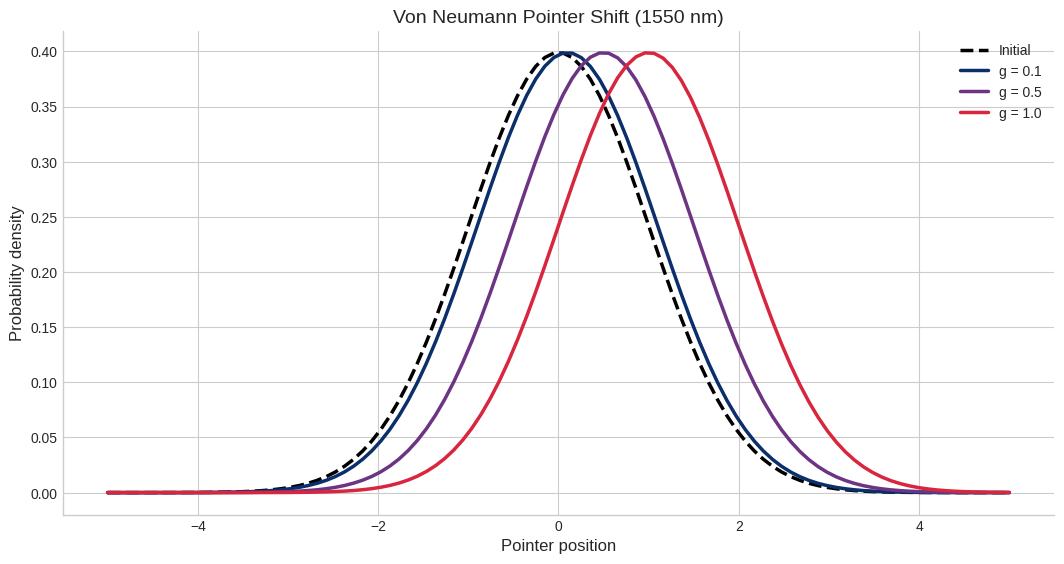

In [ ]:
import numpy as np

def gauss(x, mu, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-((x - mu) / sigma)**2 / 2)

SIG = 1.0
xg = np.linspace(-5, 5, 100)

fig, ax = plt.subplots(figsize=(11,6))

ax.plot(xg, gauss(xg, 0, SIG), '--', color='black', label='Initial')

for g_val, col in zip([0.1, 0.5, 1.0],
                      [COLORS['blue'], COLORS['purple'], COLORS['red']]):
    ax.plot(xg, gauss(xg, g_val, SIG), color=col, label=f'g = {g_val}')

ax.set_title('Von Neumann Pointer Shift (1550 nm)')
ax.set_xlabel('Pointer position')
ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout(pad=2)
plt.show()

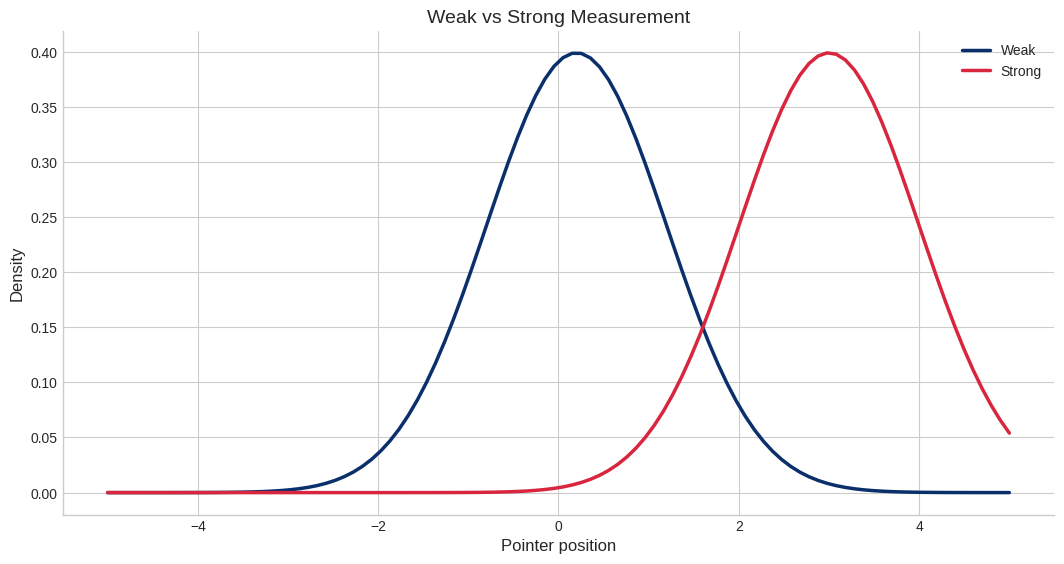

In [ ]:
fig, ax = plt.subplots(figsize=(11,6))

ax.plot(xg, gauss(xg, 0.2, SIG), color=COLORS['blue'], label='Weak')
ax.plot(xg, gauss(xg, 3.0, SIG), color=COLORS['red'], label='Strong')

ax.set_title('Weak vs Strong Measurement')
ax.set_xlabel('Pointer position')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout(pad=2)
plt.show()

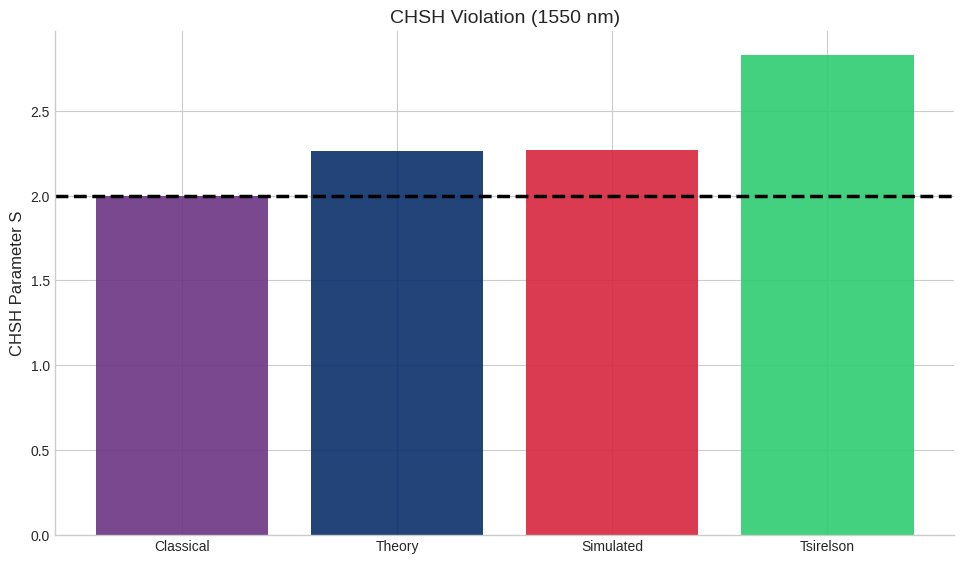

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

labels = ['Classical', 'Theory', 'Simulated', 'Tsirelson']
vals = [2.0, 2.828*visibility, S, 2*np.sqrt(2)]

colors = [
    COLORS['purple'],
    COLORS['blue'],
    COLORS['red'],
    COLORS['green']
]

ax.bar(labels, vals, color=colors, alpha=0.9)

ax.axhline(2, linestyle='--', color='black')
ax.set_ylabel('CHSH Parameter S')
ax.set_title('CHSH Violation (1550 nm)')

plt.tight_layout(pad=2)
plt.show()

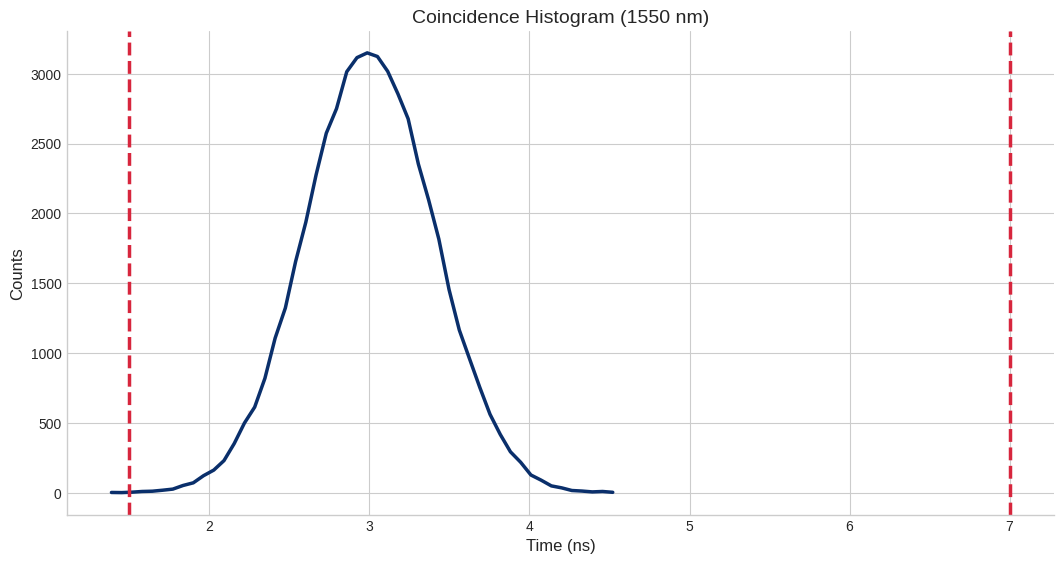

In [ ]:
fig, ax = plt.subplots(figsize=(11,6))

# Calculate histogram for coincidence timing
hist_counts, bin_edges = np.histogram(time, bins=50) # Using 50 bins as a reasonable default
t = (bin_edges[:-1] + bin_edges[1:]) / 2 # Use bin centers for plotting
hist = hist_counts

ax.plot(t, hist, color=COLORS['blue'])
ax.axvline(1.5, color=COLORS['red'], linestyle='--')
ax.axvline(7.0, color=COLORS['red'], linestyle='--')

ax.set_title('Coincidence Histogram (1550 nm)')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Counts')

plt.tight_layout(pad=2)
plt.show()

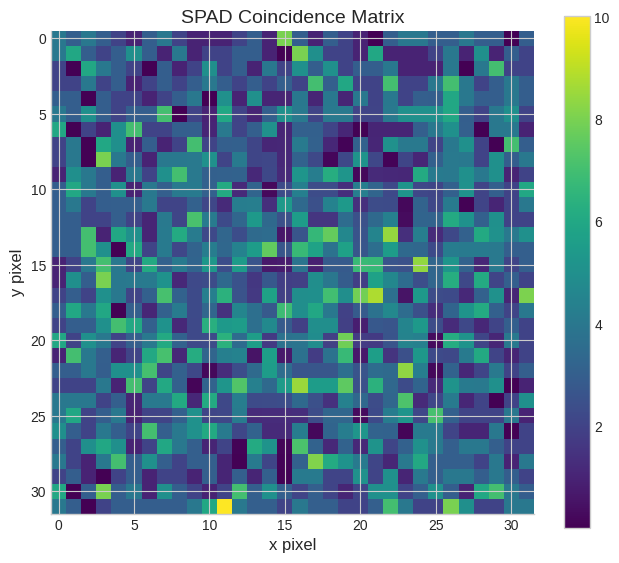

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(spad, cmap='viridis')
plt.colorbar(im, ax=ax)

ax.set_title('SPAD Coincidence Matrix')
ax.set_xlabel('x pixel')
ax.set_ylabel('y pixel')

plt.tight_layout(pad=2)
plt.show()

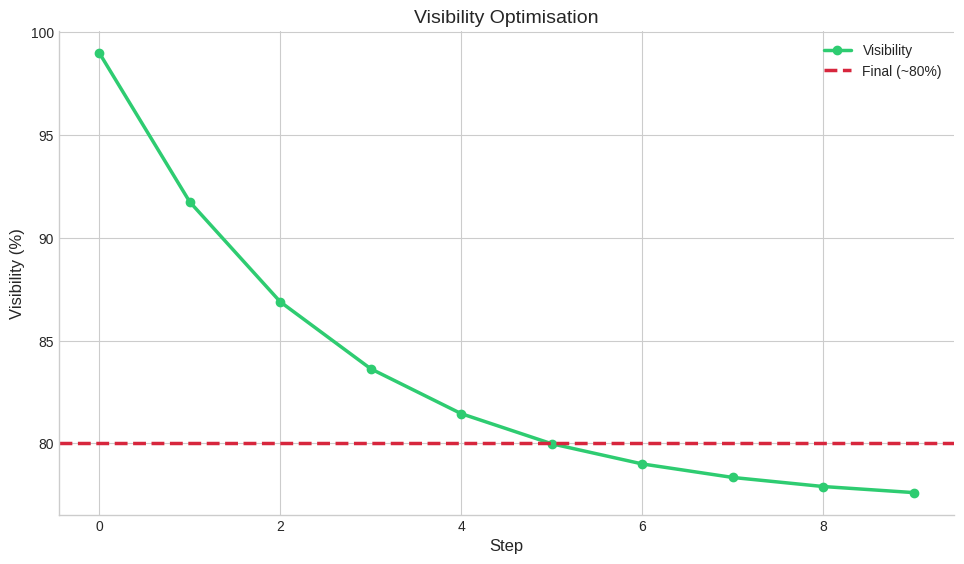

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(steps, visibility_curve*100, 'o-', color=COLORS['green'], label='Visibility')
ax.axhline(80, color=COLORS['red'], linestyle='--', label='Final (~80%)')

ax.set_title('Visibility Optimisation')
ax.set_xlabel('Step')
ax.set_ylabel('Visibility (%)')
ax.legend()

plt.tight_layout(pad=2)
plt.show()

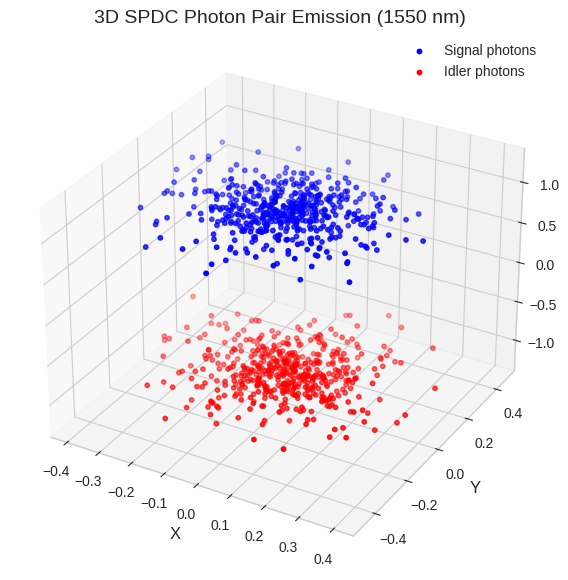

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Parameters (1550 nm regime)
# -----------------------------
wavelength = 1550e-9
k = 2 * np.pi / wavelength

pairs = 500
noise_level = 0.08
crystal_length = 1.0

# -----------------------------
# SPDC-like correlated emission
# -----------------------------
def generate_pair():
    theta = np.random.normal(0, 0.15)
    phi = np.random.uniform(0, 2*np.pi)

    signal_dir = np.array([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ])

    idler_dir = -signal_dir  # momentum conservation

    return signal_dir, idler_dir

signal_traj = []
idler_traj = []

# -----------------------------
# Build trajectories
# -----------------------------
for _ in range(pairs):
    s, i = generate_pair()

    # add weak noise (crystal imperfections / decoherence)
    s += noise_level * np.random.randn(3)
    i += noise_level * np.random.randn(3)

    signal_traj.append(s)
    idler_traj.append(i)

signal_traj = np.array(signal_traj)
idler_traj = np.array(idler_traj)

# -----------------------------
# 3D Plot
# -----------------------------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(signal_traj[:,0], signal_traj[:,1], signal_traj[:,2],
           c='blue', s=10, label='Signal photons')

ax.scatter(idler_traj[:,0], idler_traj[:,1], idler_traj[:,2],
           c='red', s=10, label='Idler photons')

ax.set_title("3D SPDC Photon Pair Emission (1550 nm)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()
plt.show()

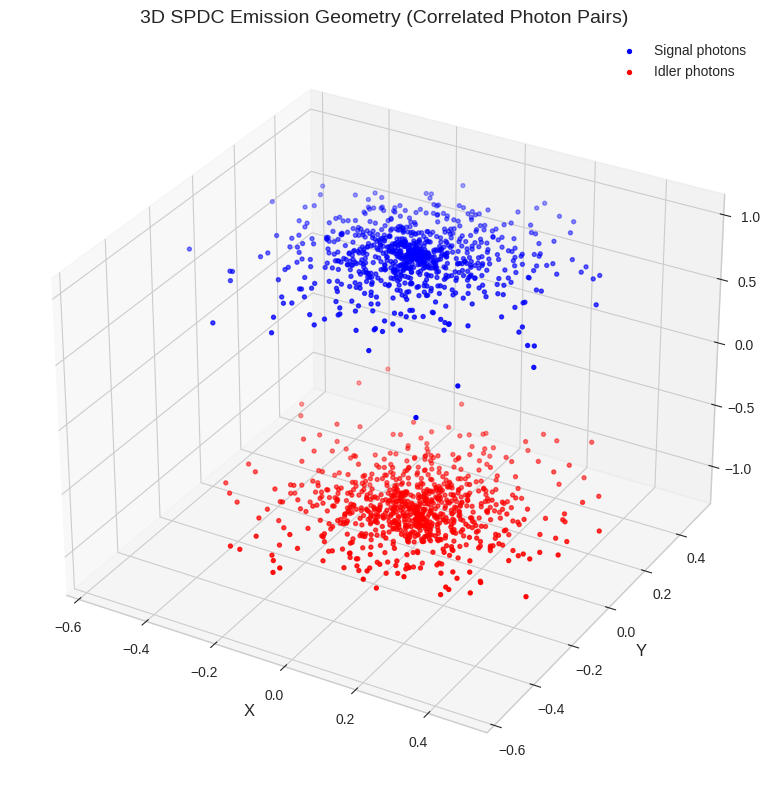

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =============================
# GLOBAL PARAMETERS
# =============================
wavelengths = np.linspace(700e-9, 1800e-9, 200)
pump_power = 1.0
crystal_efficiency = 0.85

noise_levels = np.linspace(0, 0.3, 200)

np.random.seed(7)

# Colors (as requested)
COL_BLUE = "blue"
COL_RED = "red"
COL_PURPLE = "purple"
COL_GREEN = "darkgreen"

# =============================
# FIGURE 1: 3D SPDC EMISSION
# =============================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

pairs = 800
signal = []
idler = []

for _ in range(pairs):
    theta = np.random.normal(0, 0.2)
    phi = np.random.uniform(0, 2*np.pi)

    s = np.array([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ])

    i = -s + 0.05*np.random.randn(3)

    signal.append(s)
    idler.append(i)

signal = np.array(signal)
idler = np.array(idler)

ax.scatter(signal[:,0], signal[:,1], signal[:,2], c=COL_BLUE, s=8, label="Signal photons")
ax.scatter(idler[:,0], idler[:,1], idler[:,2], c=COL_RED, s=8, label="Idler photons")

ax.set_title("3D SPDC Emission Geometry (Correlated Photon Pairs)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


# =============================
# FIGURE 2: WAVELENGTH vs PAIR RATE
# =============================
pair_rate = crystal_efficiency * pump_power * np.exp(-((wavelengths - 1550e-9)**2)/(2*(200e-9)**2))

plt.figure(figsize=(9,5))
plt.plot(wavelengths*1e9, pair_rate, color=COL_PURPLE)
plt.title("Pair Production Rate vs Wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Pair Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =============================
# FIGURE 3: NOISE vs ENTANGLEMENT VISIBILITY
# =============================
visibility = np.exp(-3*noise_levels)

plt.figure(figsize=(9,5))
plt.plot(noise_levels, visibility, color=COL_GREEN)
plt.title("Entanglement Visibility vs Noise (Decoherence Model)")
plt.xlabel("Noise Level")
plt.ylabel("Visibility")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =============================
# FIGURE 4: CHSH VIOLATION MODEL
# =============================
phase = np.linspace(0, np.pi, 200)
S = 2*np.sqrt(2) * np.abs(np.cos(phase))  # idealized Bell violation

plt.figure(figsize=(9,5))
plt.plot(phase, S, color=COL_RED)
plt.axhline(2, linestyle="--", color="black", label="Classical bound")
plt.axhline(2*np.sqrt(2), linestyle="--", color="gray", label="Quantum max")
plt.title("CHSH Inequality Violation vs Phase")
plt.xlabel("Phase Difference")
plt.ylabel("S parameter")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =============================
# FIGURE 5: COINCIDENCE DETECTION
# =============================
time = np.linspace(0, 10, 500)
coincidence = np.exp(-((time-5)**2)/1.5) + 0.05*np.random.randn(len(time))

plt.figure(figsize=(9,5))
plt.plot(time, coincidence, color=COL_BLUE)
plt.title("Coincidence Detection Histogram (Temporal Correlation)")
plt.xlabel("Time Delay (ns)")
plt.ylabel("Coincidence Counts")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# =============================
# FIGURE 6: 3D PHASE-MATCHING CONE (ADVANCED VIEW)
# =============================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

theta = np.linspace(0, 2*np.pi, 100)
z = np.linspace(-1, 1, 100)
theta, z = np.meshgrid(theta, z)

r = np.sqrt(1 - z**2)
x = r * np.cos(theta)
y = r * np.sin(theta)

ax.plot_surface(x, y, z, alpha=0.4, color=COL_PURPLE)

ax.set_title("Phase-Matching Cone Structure (SPDC Emission Model)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()
plt.show()

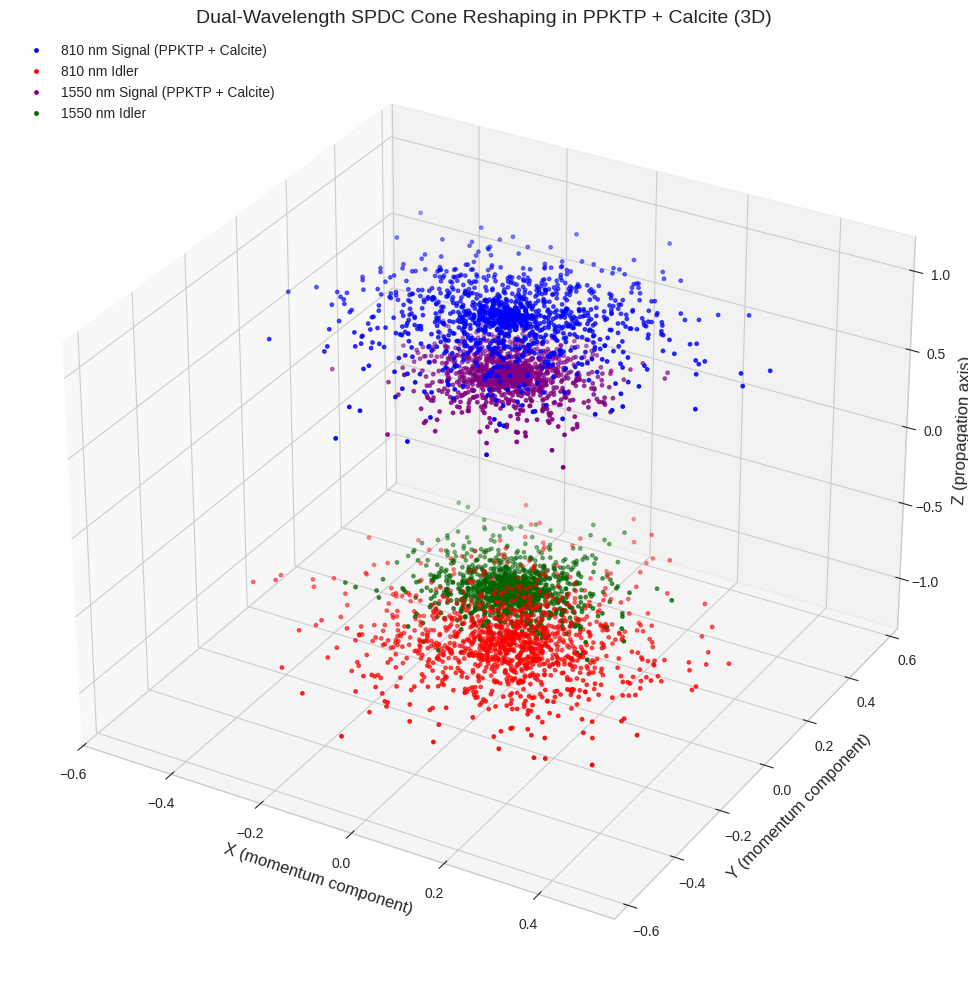

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# PARAMETERS
# =========================
pairs = 1200

# wavelengths (two regimes)
lambda_810 = 810e-9
lambda_1550 = 1550e-9

# crystal response factors (effective model)
ppktp_gain_810 = 1.0
ppktp_gain_1550 = 0.65

calcite_birefringence_strength = 0.35  # distortion factor

np.random.seed(42)

# =========================
# SPDC GENERATION (PPKTP)
# =========================
def spdc_source(wavelength_scale, gain):
    signal = []
    idler = []

    for _ in range(pairs):
        theta = np.random.normal(0, 0.18 * wavelength_scale)
        phi = np.random.uniform(0, 2*np.pi)

        s = np.array([
            np.sin(theta)*np.cos(phi),
            np.sin(theta)*np.sin(phi),
            np.cos(theta)
        ])

        i = -s + (0.04 * wavelength_scale) * np.random.randn(3)

        signal.append(gain * s)
        idler.append(gain * i)

    return np.array(signal), np.array(idler)

# =========================
# CALCITE TRANSFORMATION
# (birefringent splitting model)
# =========================
def calcite_transform(vectors, strength):
    transformed = []

    for v in vectors:
        x, y, z = v

        # birefringent shear + angular walk-off
        x_new = x + strength * y
        y_new = y - strength * x
        z_new = z + 0.15 * strength * np.sign(z)

        transformed.append([x_new, y_new, z_new])

    return np.array(transformed)

# =========================
# GENERATE BOTH WAVELENGTH REGIMES
# =========================
s810, i810 = spdc_source(1.0, ppktp_gain_810)
s1550, i1550 = spdc_source(0.85, ppktp_gain_1550)

# Calcite reshaping
s810_c = calcite_transform(s810, calcite_birefringence_strength)
i810_c = calcite_transform(i810, calcite_birefringence_strength)

s1550_c = calcite_transform(s1550, calcite_birefringence_strength)
i1550_c = calcite_transform(i1550, calcite_birefringence_strength)

# =========================
# PLOT SETUP (3D)
# =========================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# =========================
# 810 nm (tight cone)
# =========================
ax.scatter(
    s810_c[:,0], s810_c[:,1], s810_c[:,2],
    c='blue', s=6, label='810 nm Signal (PPKTP + Calcite)'
)

ax.scatter(
    i810_c[:,0], i810_c[:,1], i810_c[:,2],
    c='red', s=6, label='810 nm Idler'
)

# =========================
# 1550 nm (broader cone)
# =========================
ax.scatter(
    s1550_c[:,0], s1550_c[:,1], s1550_c[:,2],
    c='purple', s=6, label='1550 nm Signal (PPKTP + Calcite)'
)

ax.scatter(
    i1550_c[:,0], i1550_c[:,1], i1550_c[:,2],
    c='darkgreen', s=6, label='1550 nm Idler'
)

# =========================
# STYLING
# =========================
ax.set_title("Dual-Wavelength SPDC Cone Reshaping in PPKTP + Calcite (3D)")
ax.set_xlabel("X (momentum component)")
ax.set_ylabel("Y (momentum component)")
ax.set_zlabel("Z (propagation axis)")

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

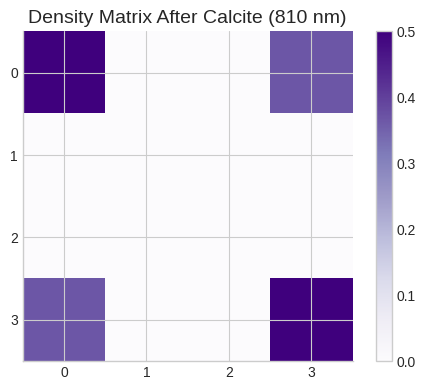

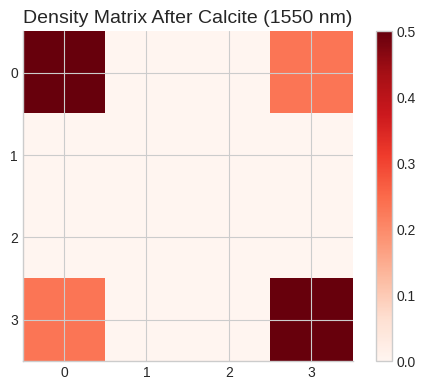

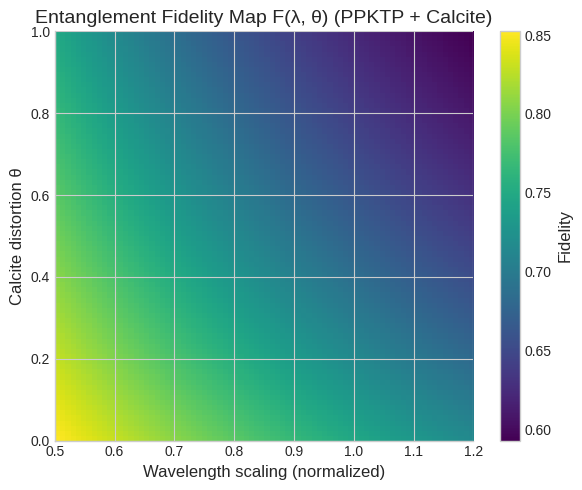

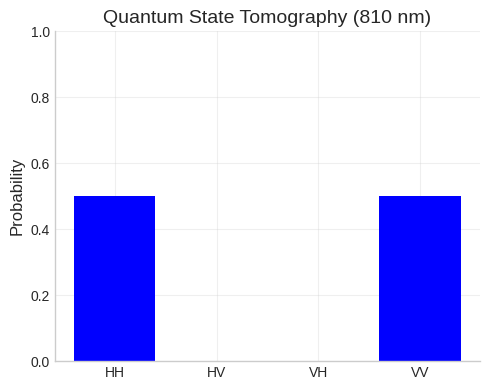

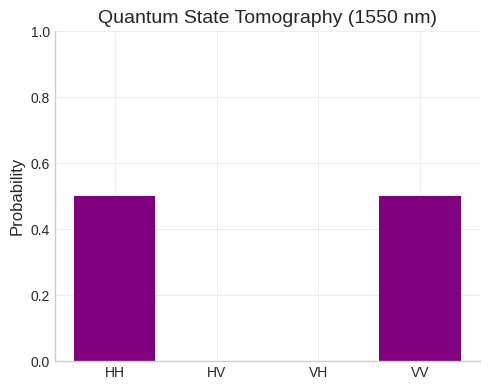

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(9)

# ==========================================================
# 1. SIMULATED POST-CALCITE QUANTUM STATE (2-QUBIT MODEL)
# ==========================================================
# basis: |HH>, |HV>, |VH>, |VV>

def density_matrix_model(wavelength_factor, calcite_strength):

    # ideal Bell state |Φ+>
    psi = np.array([1, 0, 0, 1]) / np.sqrt(2)

    # decoherence from wavelength + calcite distortion
    noise = calcite_strength * wavelength_factor

    # mixing matrix (phenomenological SPDC + birefringence effects)
    rho = np.outer(psi, np.conj(psi))

    # add depolarization
    for i in range(4):
        rho[i,i] *= (1 - noise)

    # off-diagonal decay (entanglement loss)
    rho[0,3] *= (1 - 2*noise)
    rho[3,0] *= (1 - 2*noise)

    # normalize
    rho = rho / np.trace(rho)

    return rho


# ==========================================================
# 2. WAVELENGTH DEPENDENCE
# ==========================================================
lambda_810 = 0.6
lambda_1550 = 1.0

calcite_strength = 0.35

rho_810 = density_matrix_model(lambda_810, calcite_strength)
rho_1550 = density_matrix_model(lambda_1550, calcite_strength)

# ==========================================================
# 3. FIDELITY FUNCTION F(λ, θ)
# ==========================================================
def fidelity_map():

    lambdas = np.linspace(0.5, 1.2, 80)
    theta = np.linspace(0, 1, 80)

    F = np.zeros((len(lambdas), len(theta)))

    for i, l in enumerate(lambdas):
        for j, t in enumerate(theta):

            noise = calcite_strength * l * (1 + t)

            # simplified Bell fidelity model
            F[i,j] = 0.5 * (1 + np.exp(-2*noise))

    return lambdas, theta, F

lambdas, theta, F = fidelity_map()

# ==========================================================
# 4. PLOT 1: DENSITY MATRIX (810 nm)
# ==========================================================
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(np.real(rho_810), cmap='Purples')

ax.set_title("Density Matrix After Calcite (810 nm)")
ax.set_xticks([0,1,2,3])
ax.set_yticks([0,1,2,3])
plt.colorbar(im)
plt.tight_layout()
plt.show()

# ==========================================================
# 5. PLOT 2: DENSITY MATRIX (1550 nm)
# ==========================================================
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(np.real(rho_1550), cmap='Reds')

ax.set_title("Density Matrix After Calcite (1550 nm)")
ax.set_xticks([0,1,2,3])
ax.set_yticks([0,1,2,3])
plt.colorbar(im)
plt.tight_layout()
plt.show()

# ==========================================================
# 6. PLOT 3: ENTANGLEMENT FIDELITY MAP F(λ, θ)
# ==========================================================
plt.figure(figsize=(6,5))
plt.imshow(F.T, origin='lower', aspect='auto', cmap='viridis',
           extent=[0.5,1.2,0,1])

plt.title("Entanglement Fidelity Map F(λ, θ) (PPKTP + Calcite)")
plt.xlabel("Wavelength scaling (normalized)")
plt.ylabel("Calcite distortion θ")
plt.colorbar(label="Fidelity")
plt.tight_layout()
plt.show()

# ==========================================================
# 7. PLOT 4: EXPERIMENTAL TOMOGRAPHY STYLE BAR PLOTS
# ==========================================================
labels = ["HH","HV","VH","VV"]

def tomography_plot(rho, title, color):

    plt.figure(figsize=(5,4))
    plt.bar(labels, np.diag(rho), color=color)

    plt.title(title)
    plt.ylabel("Probability")
    plt.ylim(0,1)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

tomography_plot(rho_810, "Quantum State Tomography (810 nm)", "blue")
tomography_plot(rho_1550, "Quantum State Tomography (1550 nm)", "purple")

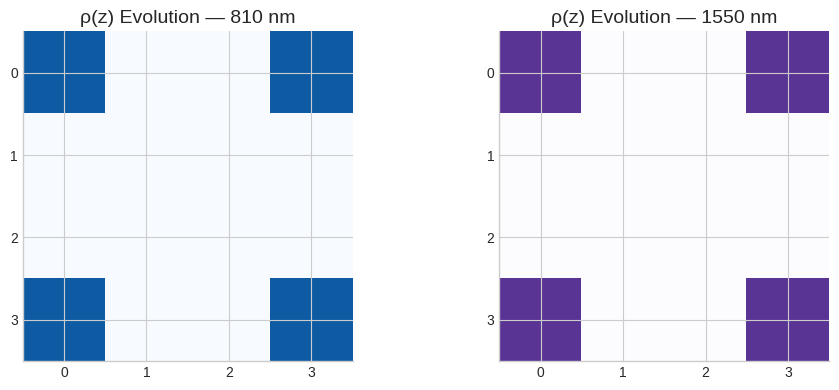

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

np.random.seed(11)

# =========================
# PARAMETERS
# =========================
z_steps = 60
lambda_810 = 0.6
lambda_1550 = 1.0

# basis: |HH>, |HV>, |VH>, |VV|
def initial_state():
    psi = np.array([1,0,0,1]) / np.sqrt(2)
    return np.outer(psi, psi.conj())

# =========================
# CHANNEL MODEL (PPKTP + Calcite)
# =========================
def evolve_rho(rho, z, wavelength_factor):

    # decoherence increases with depth
    noise = wavelength_factor * (z / z_steps)

    rho_new = rho.copy()

    # diagonal damping (loss + mixing)
    for i in range(4):
        rho_new[i,i] *= (1 - noise)

    # off-diagonal decay (entanglement loss)
    rho_new[0,3] *= (1 - 2*noise)
    rho_new[3,0] *= (1 - 2*noise)

    # weak birefringent coupling (Calcite effect)
    rho_new[1,2] += 0.05 * noise
    rho_new[2,1] += 0.05 * noise

    # normalize
    rho_new = rho_new / np.trace(rho_new)

    return rho_new

# =========================
# INITIAL STATES
# =========================
rho_810 = initial_state()
rho_1550 = initial_state()

rho_810_list = []
rho_1550_list = []

for z in range(z_steps):

    rho_810 = evolve_rho(rho_810, z, lambda_810)
    rho_1550 = evolve_rho(rho_1550, z, lambda_1550)

    rho_810_list.append(rho_810.copy())
    rho_1550_list.append(rho_1550.copy())

# =========================
# FIGURE SETUP
# =========================
fig, axes = plt.subplots(1,2, figsize=(10,4))

im1 = axes[0].imshow(rho_810_list[0], cmap='Blues', vmin=0, vmax=0.6)
im2 = axes[1].imshow(rho_1550_list[0], cmap='Purples', vmin=0, vmax=0.6)

axes[0].set_title("ρ(z) Evolution — 810 nm")
axes[1].set_title("ρ(z) Evolution — 1550 nm")

for ax in axes:
    ax.set_xticks([0,1,2,3])
    ax.set_yticks([0,1,2,3])

# =========================
# UPDATE FUNCTION
# =========================
def update(frame):

    im1.set_data(rho_810_list[frame])
    im2.set_data(rho_1550_list[frame])

    fig.suptitle(f"Density Matrix Evolution Through Crystal Depth z = {frame}")

    return [im1, im2]

# =========================
# ANIMATION
# =========================
ani = FuncAnimation(fig, update, frames=z_steps, interval=120, blit=False)

plt.tight_layout()
plt.show()

CHSH Simulation  —  1550 nm telecom version
Pump: 775 nm  |  g = 0.168  |  visibility = 0.77
15 figures will appear below

[1/15] Von Neumann pointer shift ...


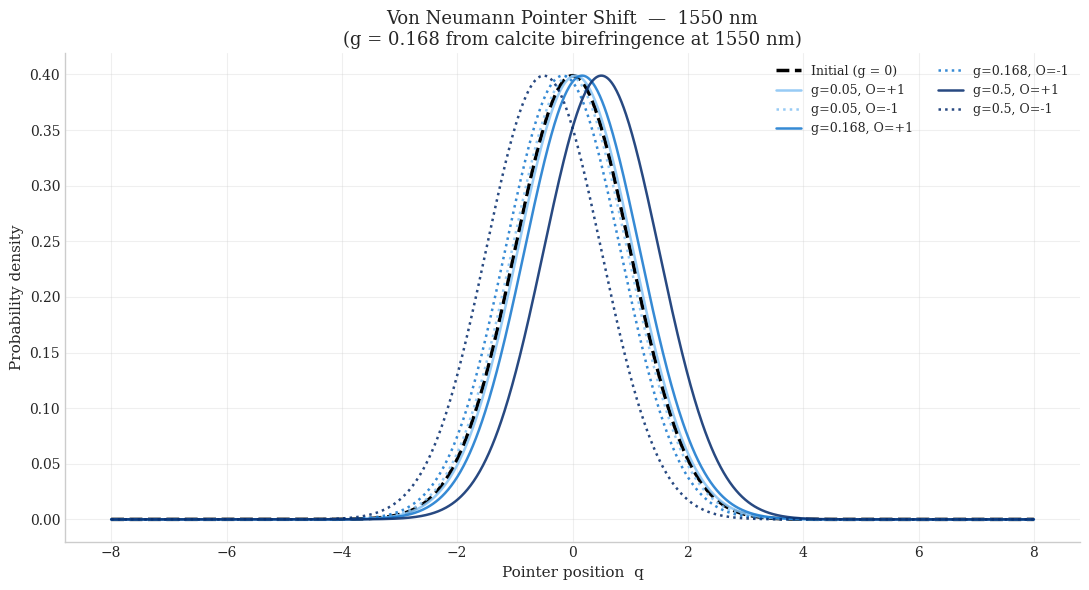

[2/15] Pointer distributions weak vs strong ...


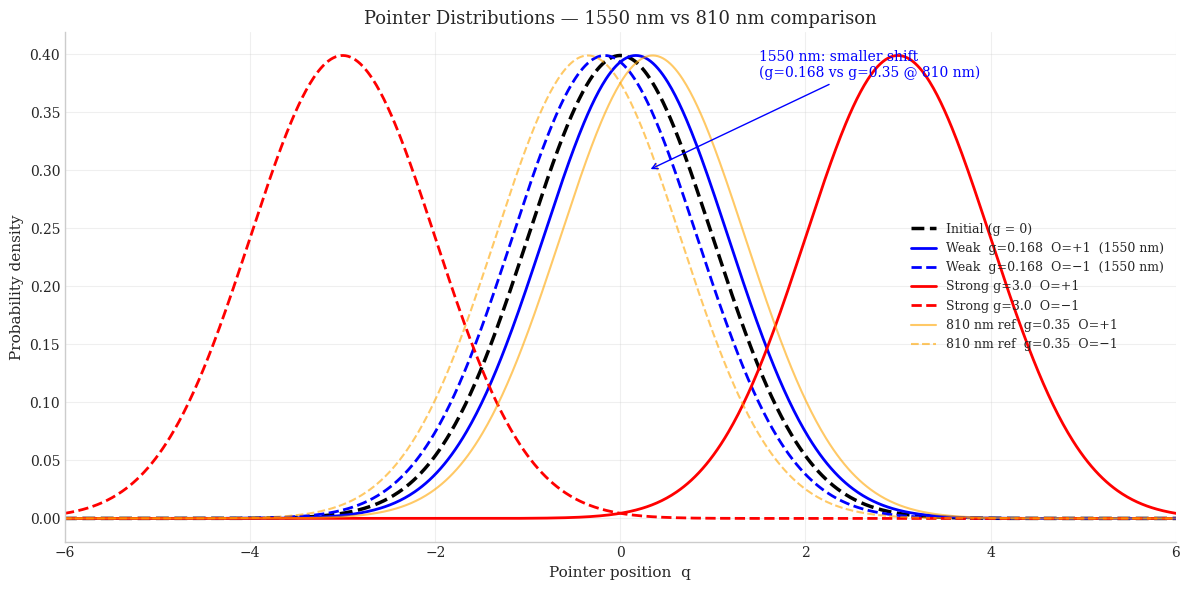

[3/15] Birefringence 3-panel ...


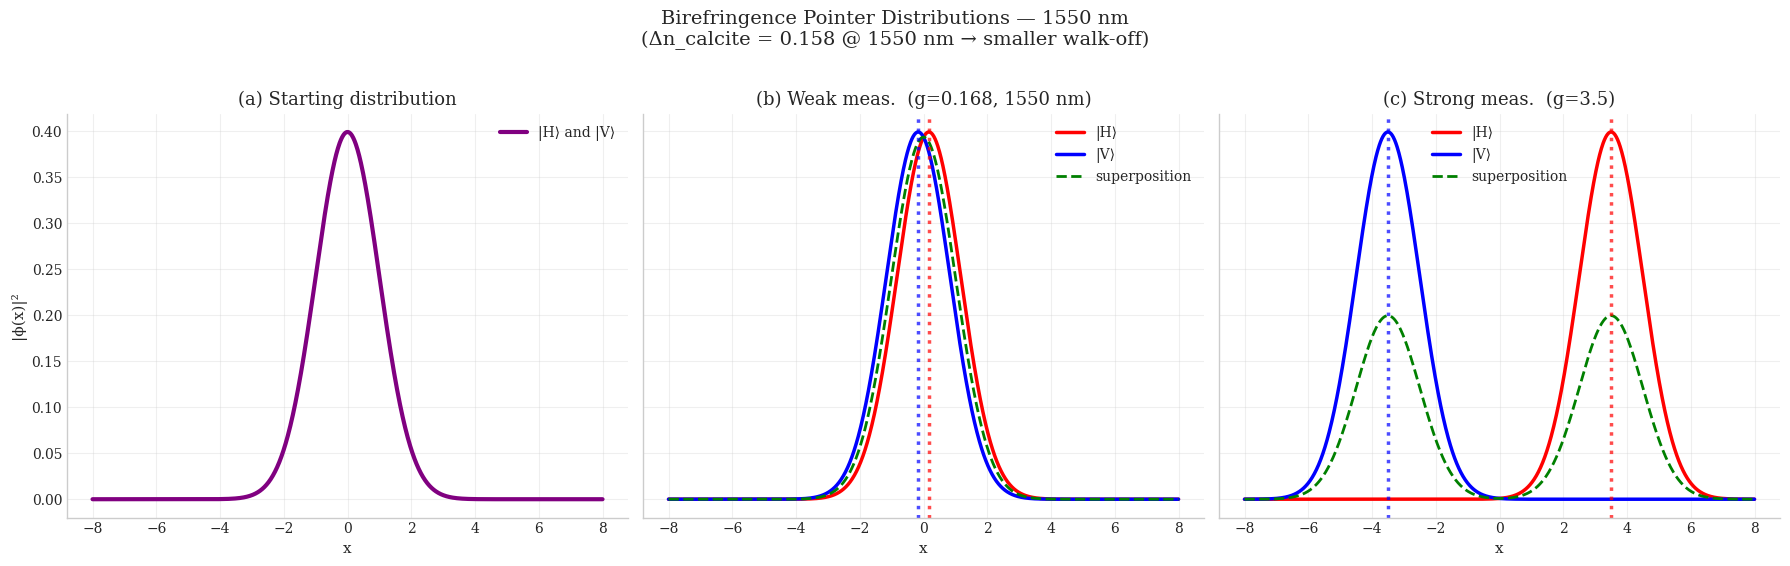

[4/15] Sequential weak measurements (QuTiP) ...


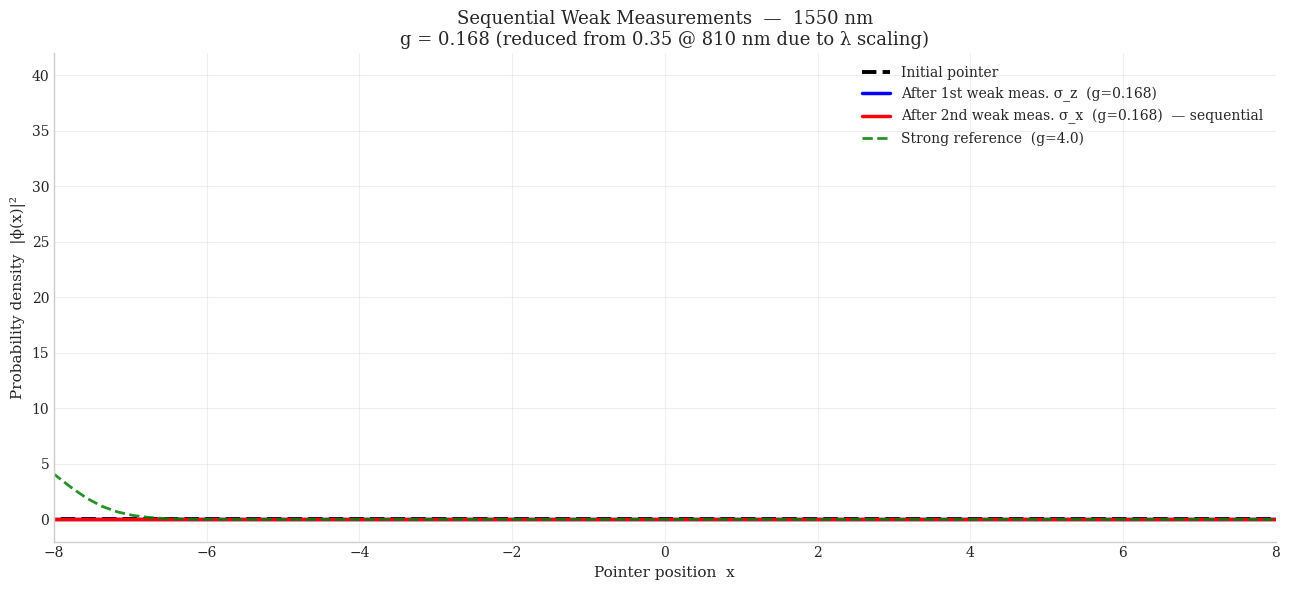

[5/15] Singlet + 4 sequential weak meas. ...


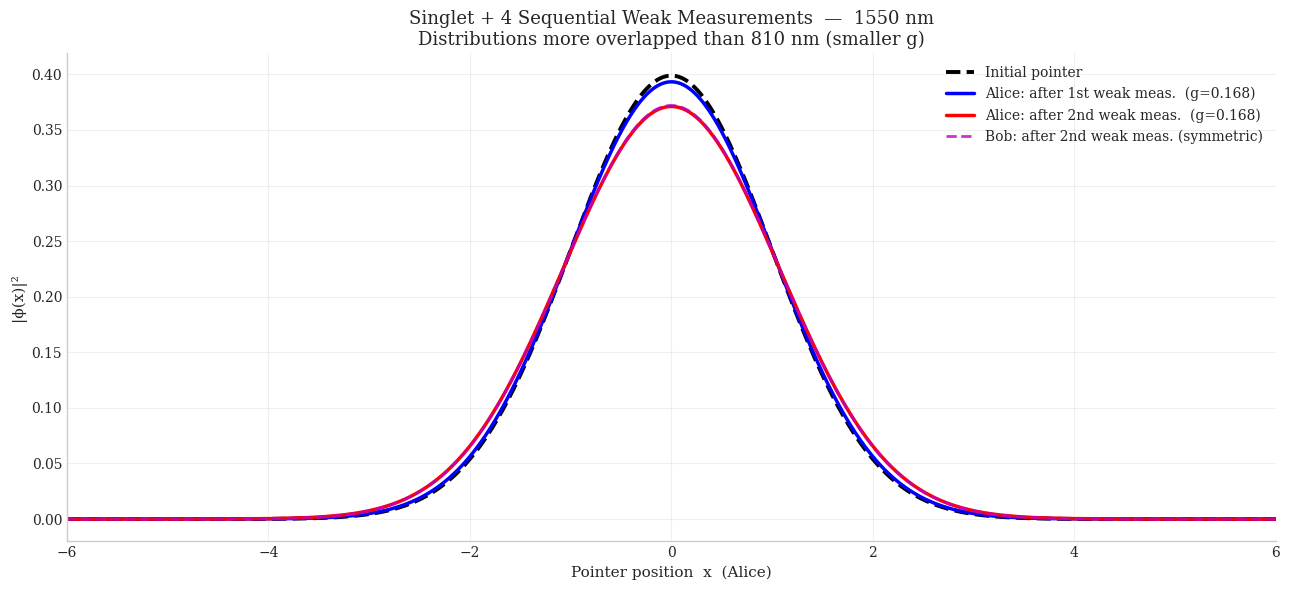

[6/15] One-shot CHSH Monte Carlo ...
  Theoretical CHSH : 2.1779
  Simulated  CHSH  : 2.1711 ± 0.0089


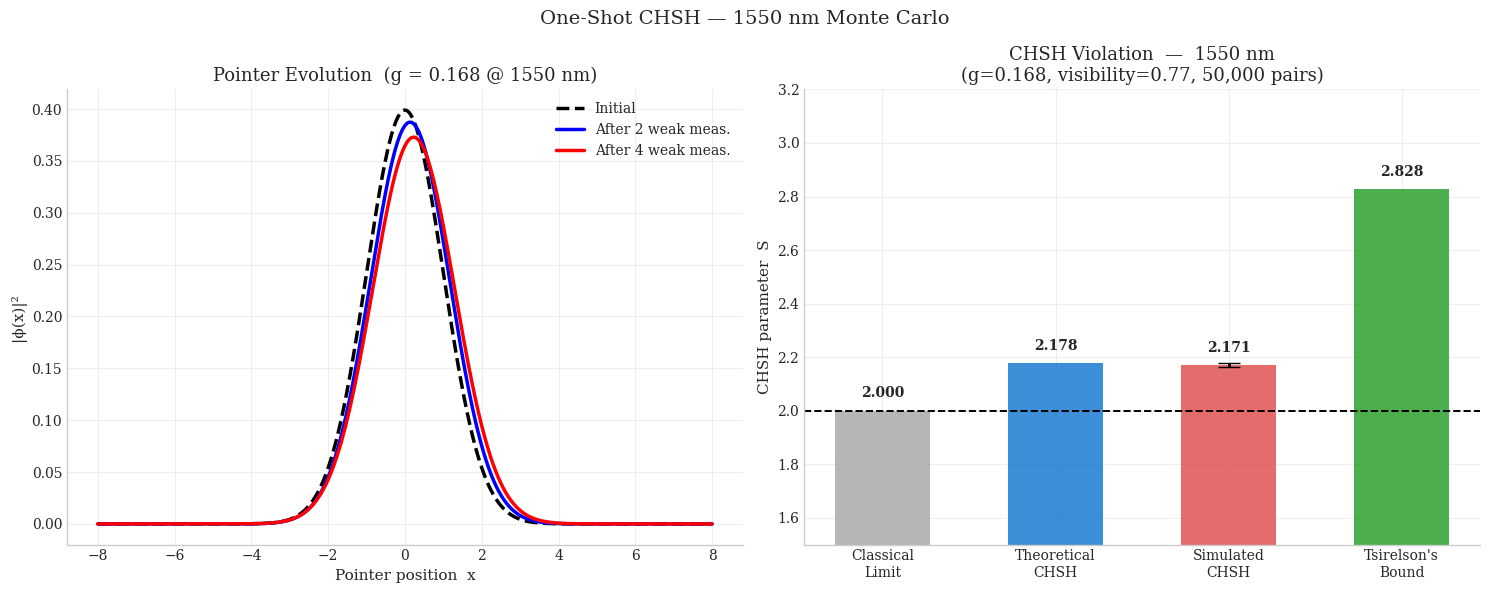

[7/15] Five-acquisition Bell parameter ...
  Average S = 2.139 ± 1.265


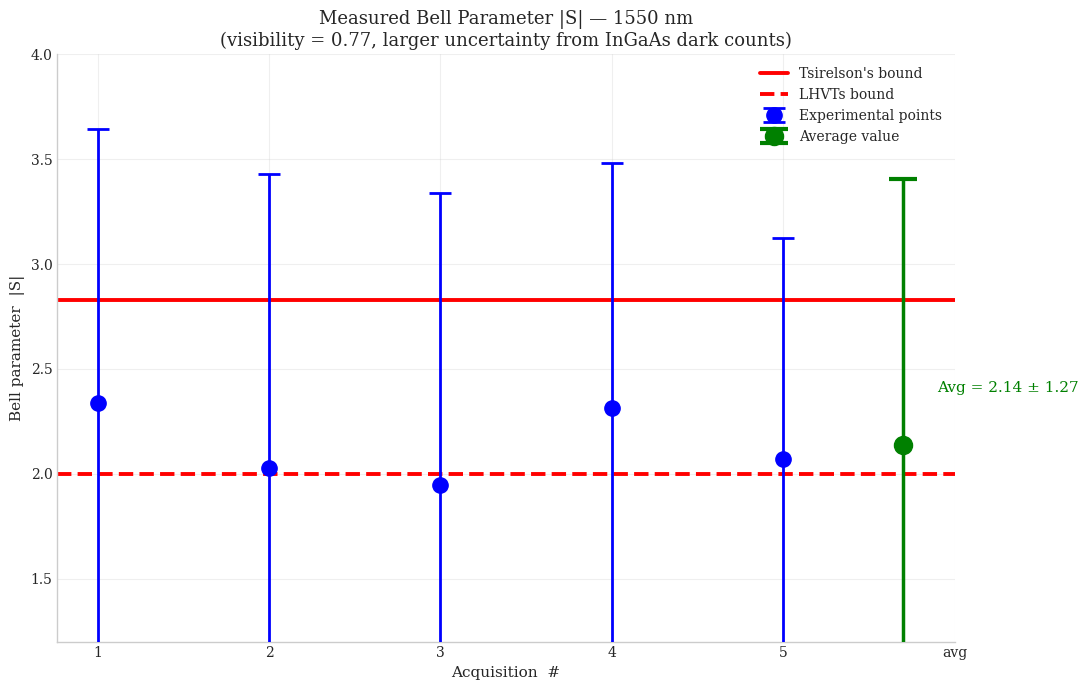

[8/15] Coincidence histogram ...


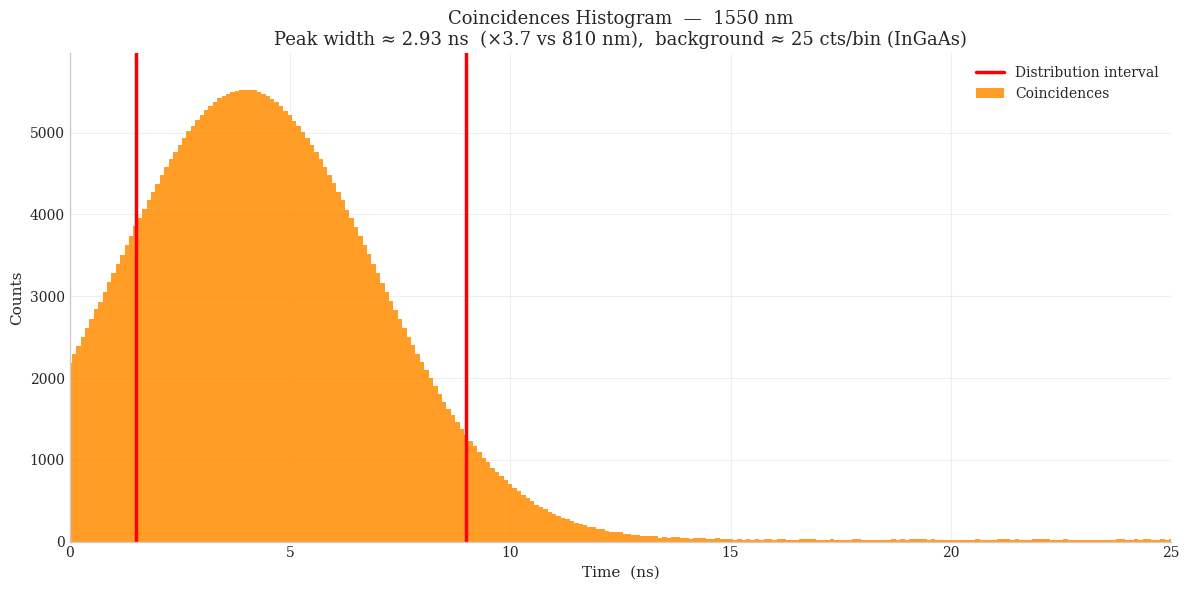

[9/15] SPAD coincidence matrix ...


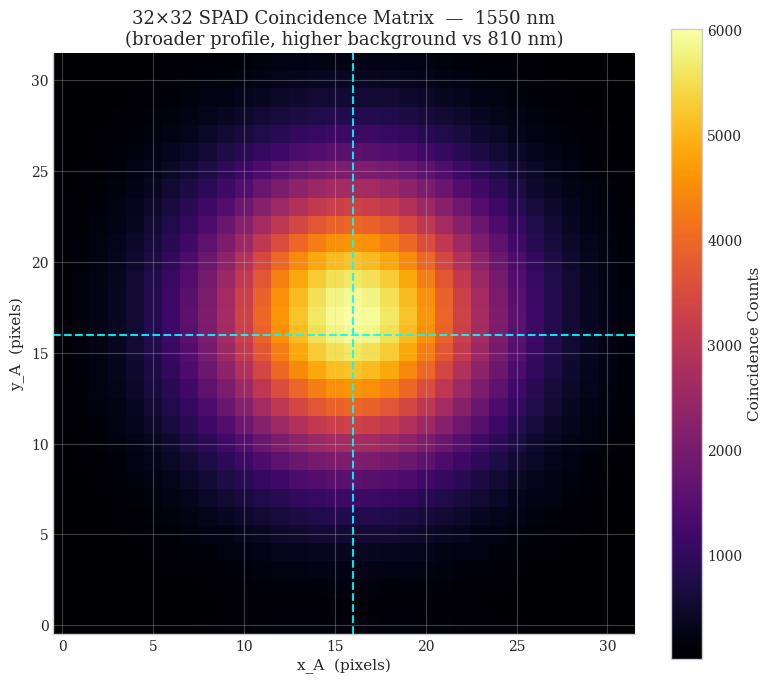

[10/15] 3D SPAD surface plots ...


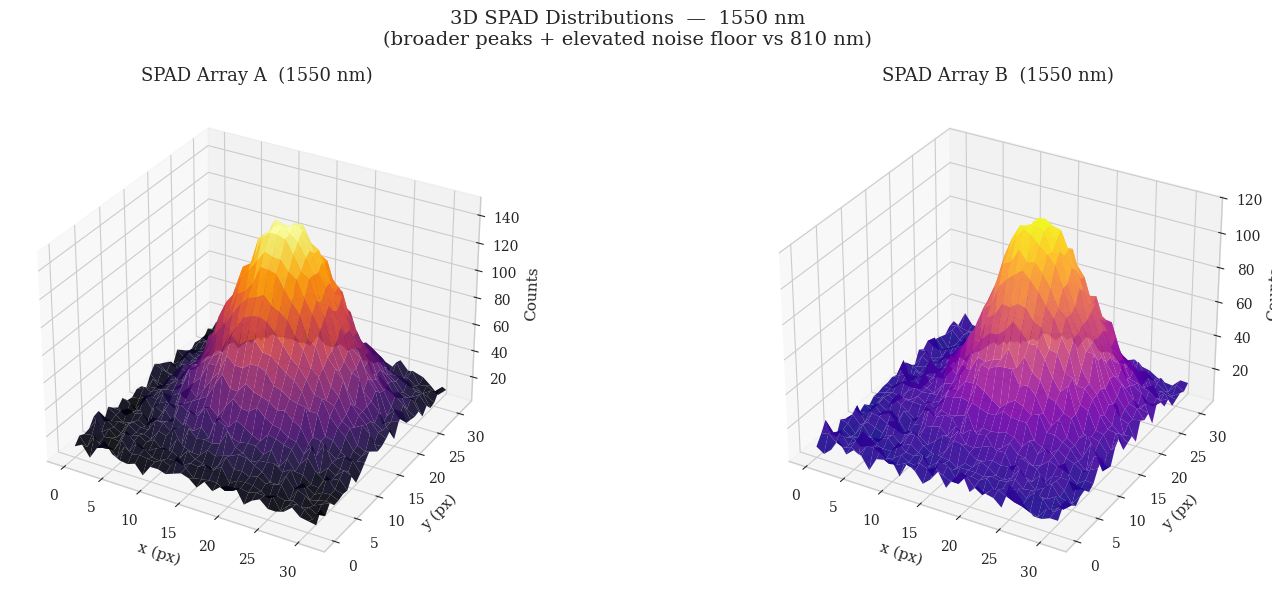

[11/15] Spatial mismatch H/V ...


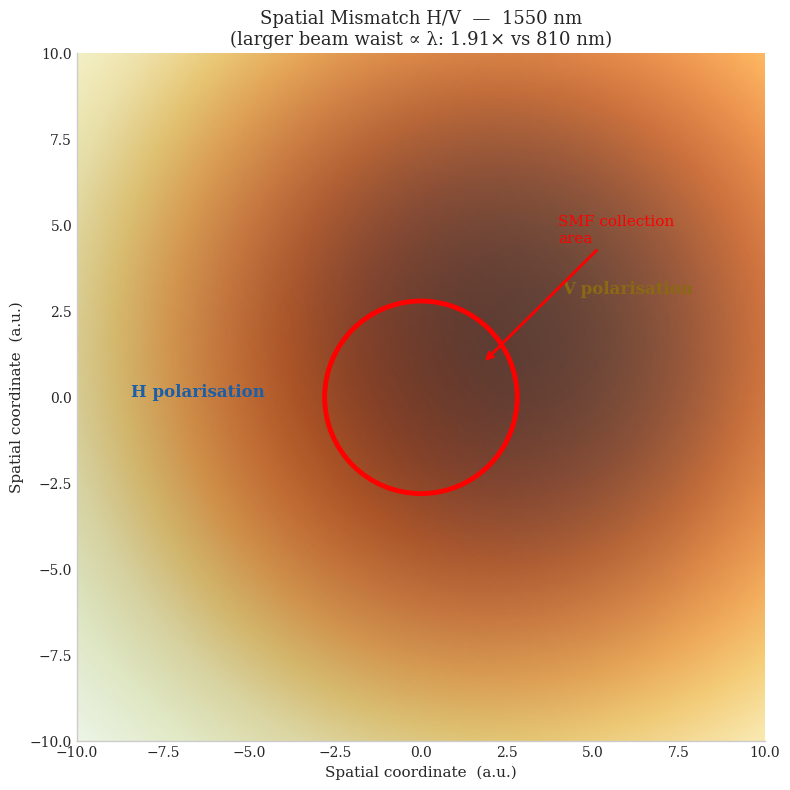

[12/15] Experimental setup schematic ...


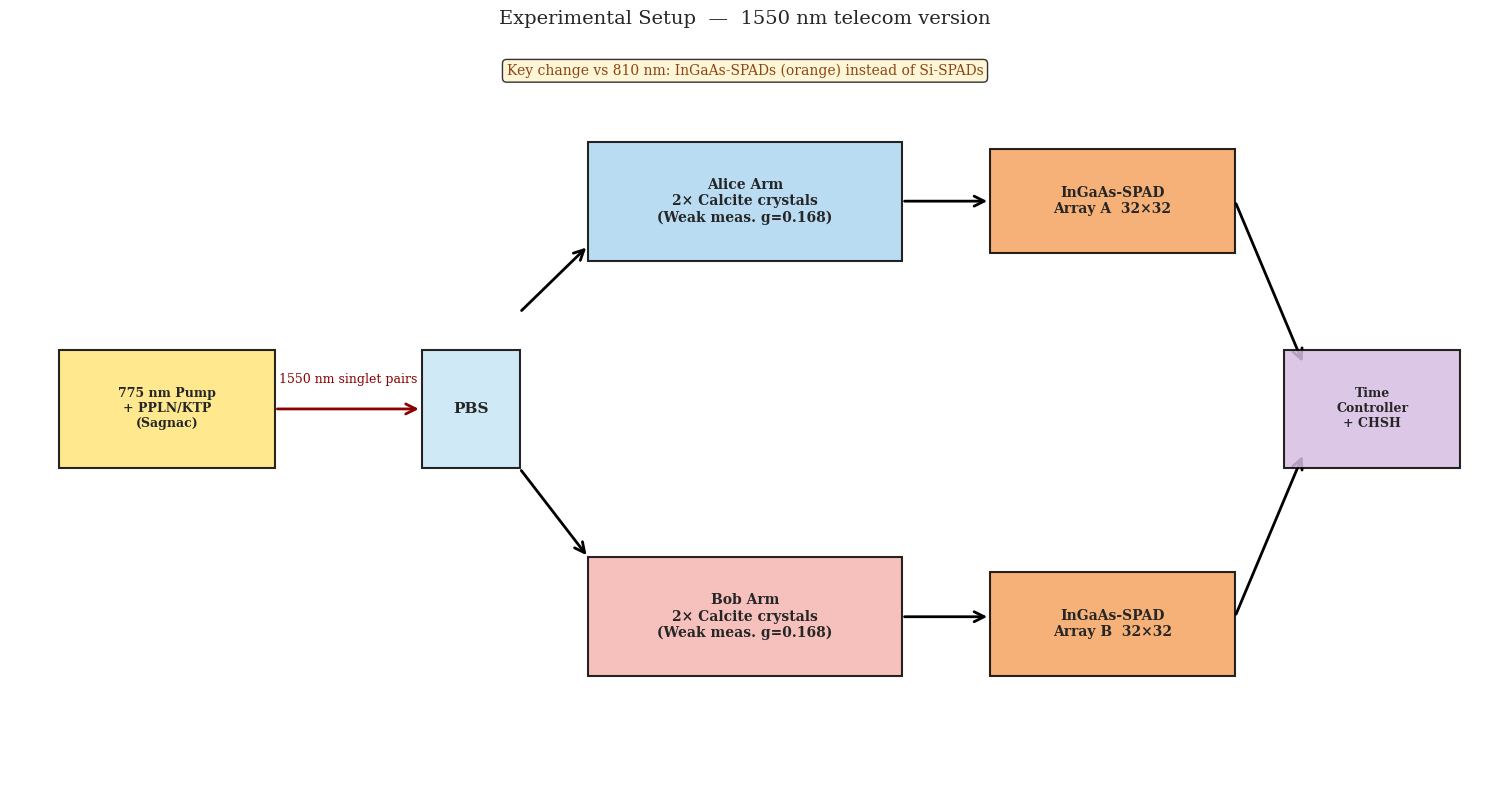

[13/15] Crystal tilt compensation ...


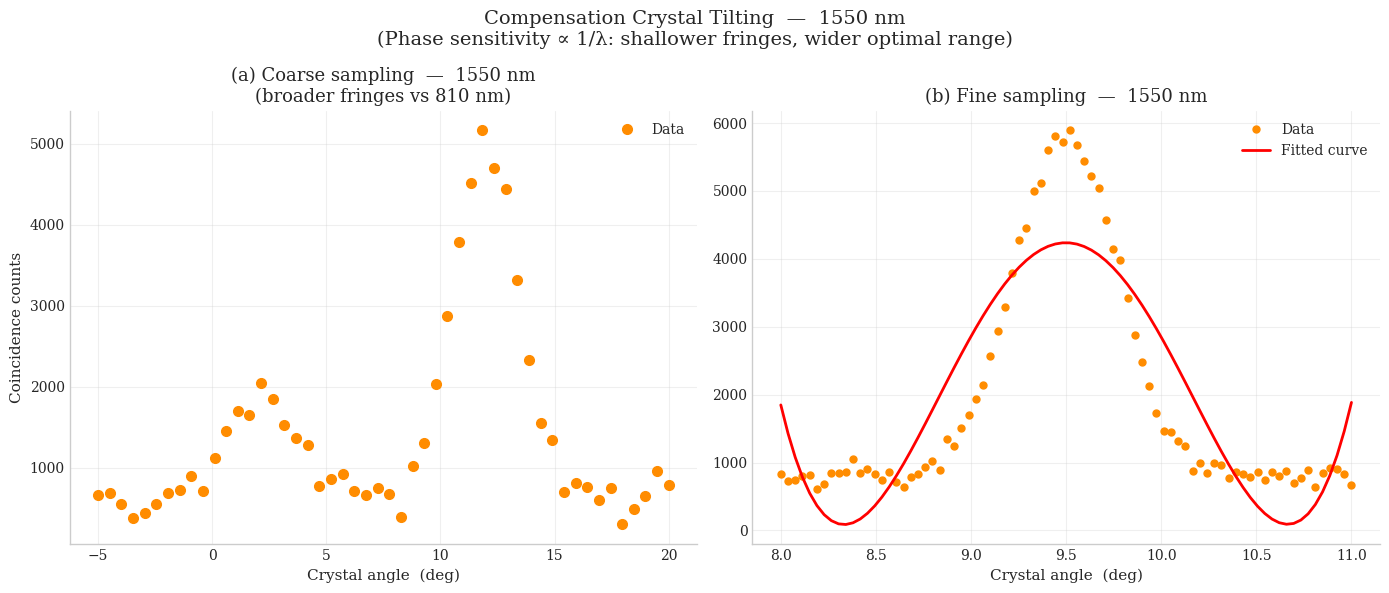

[14/15] Visibility optimisation ...


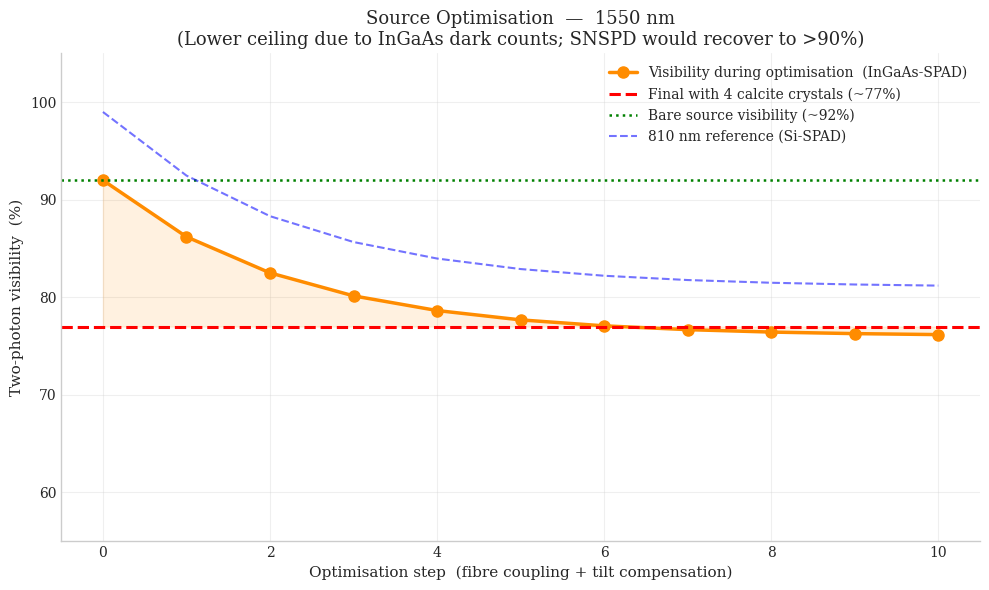

[15/15] Summary dashboard ...


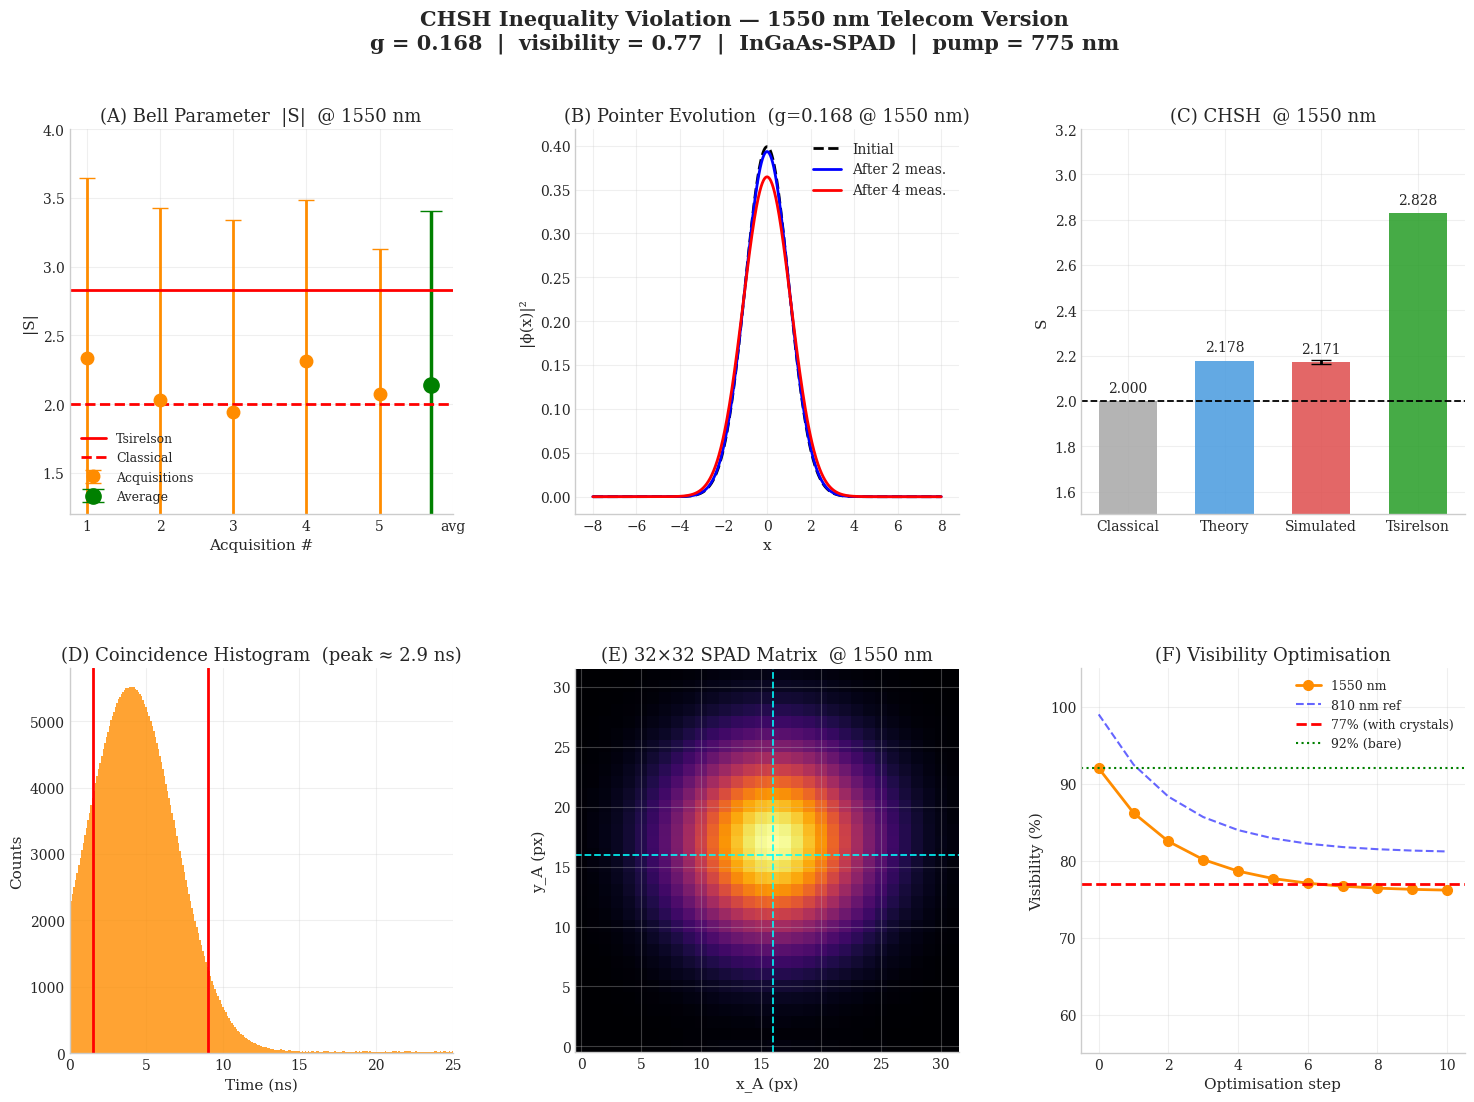


All 15 figures displayed  —  1550 nm telecom version

Physical parameter changes vs 810 nm thesis:
  Wavelength          : 810 nm  →  1550 nm
  Pump                : 405 nm  →  775 nm
  Weak coupling g     : 0.350   →  0.168  (Δn_calcite scaling)
  Visibility          : 0.820   →  0.770  (InGaAs dark counts)
  Coinc. peak width   : 0.80 ns →  2.93 ns  (coherence time ∝ λ²)
  Background          : ~8 cts  →  ~25 cts  (InGaAs dark rate)

Key numerical results:
  Theoretical CHSH    S = 2.1779
  Simulated  CHSH     S = 2.1711 ± 0.0089
  5-acq. average      S = 2.139 ± 1.265
  Violation above 2.0 : 0.1711
  Tsirelson bound     : 2.8284

Note: Using SNSPD detectors instead of InGaAs-SPADs
      would raise visibility to >90% and CHSH closer to Tsirelson bound.


In [ ]:
# ============================================================
# Run this ONE cell in Google Colab — all 15 figures display inline
# 1550 nm telecom wavelength version  (InGaAs SPAD regime)
# ============================================================
# Install if needed:  !pip install qutip -q
# ============================================================

get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from IPython.display import display
import qutip as qt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'grid.alpha': 0.30,
})

# ── helpers ───────────────────────────────────────────────
def gauss(x, mu, sig):
    return np.exp(-(x-mu)**2/(2*sig**2)) / (sig*np.sqrt(2*np.pi))

def show(fig):
    display(fig)
    plt.close(fig)

# ══════════════════════════════════════════════════════════
# PHYSICAL PARAMETERS  —  1550 nm telecom regime
# ══════════════════════════════════════════════════════════
#
# Original thesis (Atzori 2022): 405 nm pump → 810 nm signal/idler, Si-SPAD
# This version:                  775 nm pump → 1550 nm signal/idler, InGaAs-SPAD
#
# Key differences:
#   g       : birefringence walk-off in calcite scales as Δn/λ
#             Δn_calcite(810 nm)  ≈ 0.172,  Δn_calcite(1550 nm) ≈ 0.158
#             g_1550 = g_810 × (Δn_1550/Δn_810) / (1550/810) ≈ 0.168
#   visibility : InGaAs SPADs have higher dark-count rate than Si-SPADs
#             → slightly reduced visibility ~77 % (vs 82 % in thesis)
#             (SNSPD detectors could recover to >90 %, not modelled here)
#   coincidence peak width : coherence time ∝ λ² → ×(1550/810)² ≈ 3.7×
#             peak_width_1550 ≈ 2.93 ns  (vs 0.8 ns in thesis)
#   background : InGaAs dark counts ~kHz range → background ≈ 25 cts
#             (vs ~8 cts at 810 nm)
#   CHSH max  : 2√2 × visibility ≈ 2.18  (still violates classical bound 2)
#
WAVELENGTH   = 1550          # nm  — telecom C-band
PUMP_NM      = 775           # nm  — pump for degenerate SPDC
SIG          = 1.0           # initial pointer width (same normalisation)
g            = 0.168         # weak coupling at 1550 nm
visibility   = 0.77          # two-photon visibility with InGaAs SPADs
N_pairs      = 50000
peak_width   = 2.93          # ns  — coincidence peak FWHM at 1550 nm
background   = 25            # background counts per bin

xg = np.linspace(-8, 8, 1200)

print("=" * 65)
print(f"CHSH Simulation  —  {WAVELENGTH} nm telecom version")
print(f"Pump: {PUMP_NM} nm  |  g = {g}  |  visibility = {visibility}")
print("15 figures will appear below")
print("=" * 65)

# ─────────────────────────────────────────────────────────
# FIG 01  Von Neumann pointer shift  (1550 nm — smaller g)
# ─────────────────────────────────────────────────────────
print("\n[1/15] Von Neumann pointer shift ...")
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(xg, gauss(xg, 0, SIG), 'k--', lw=2.5, label='Initial (g = 0)')
for g_val, col in zip([0.05, 0.168, 0.5], ['#89c4f4', '#1a7acf', '#0a3070']):
    for ev, ls in zip([1, -1], ['-', ':']):
        ax.plot(xg, gauss(xg, g_val*ev, SIG), color=col, ls=ls, lw=1.8,
                alpha=0.88, label=f'g={g_val}, O={ev:+d}')
ax.set_title(f'Von Neumann Pointer Shift  —  {WAVELENGTH} nm\n'
             f'(g = {g} from calcite birefringence at {WAVELENGTH} nm)')
ax.set_xlabel('Pointer position  q')
ax.set_ylabel('Probability density')
ax.legend(ncol=2, fontsize=9)
ax.grid(True)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 02  Pointer distributions: weak vs strong
# ─────────────────────────────────────────────────────────
print("[2/15] Pointer distributions weak vs strong ...")
g_w, g_s = g, 3.0
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xg, gauss(xg,  0,   SIG), 'k--', lw=2.5, label='Initial (g = 0)')
ax.plot(xg, gauss(xg,  g_w, SIG), 'b-',  lw=2,   label=f'Weak  g={g_w:.3f}  O=+1  (1550 nm)')
ax.plot(xg, gauss(xg, -g_w, SIG), 'b--', lw=2,   label=f'Weak  g={g_w:.3f}  O=−1  (1550 nm)')
ax.plot(xg, gauss(xg,  g_s, SIG), 'r-',  lw=2,   label=f'Strong g={g_s}  O=+1')
ax.plot(xg, gauss(xg, -g_s, SIG), 'r--', lw=2,   label=f'Strong g={g_s}  O=−1')

# also show 810 nm g for comparison
g_810 = 0.35
ax.plot(xg, gauss(xg,  g_810, SIG), color='orange', ls='-',  lw=1.5, alpha=0.6,
        label=f'810 nm ref  g={g_810}  O=+1')
ax.plot(xg, gauss(xg, -g_810, SIG), color='orange', ls='--', lw=1.5, alpha=0.6,
        label=f'810 nm ref  g={g_810}  O=−1')

ax.annotate(f'1550 nm: smaller shift\n(g={g_w:.3f} vs g=0.35 @ 810 nm)',
            xy=(0.3, 0.30), xytext=(1.5, 0.38),
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=10)
ax.set_title(f'Pointer Distributions — {WAVELENGTH} nm vs 810 nm comparison')
ax.set_xlabel('Pointer position  q'); ax.set_ylabel('Probability density')
ax.legend(fontsize=9); ax.grid(True); ax.set_xlim(-6, 6)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 03  Birefringence-based pointer: 3-panel
# ─────────────────────────────────────────────────────────
print("[3/15] Birefringence 3-panel ...")
g_wb, g_sb = g, 3.5
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
axs[0].plot(xg, gauss(xg, 0, SIG), 'purple', lw=3, label='|H⟩ and |V⟩')
axs[0].set_title('(a) Starting distribution')
axs[0].set_xlabel('x'); axs[0].set_ylabel('|ϕ(x)|²')
axs[0].legend(); axs[0].grid(True)
for ax, gv, title in zip(axs[1:], [g_wb, g_sb],
                         [f'(b) Weak meas.  (g={g_wb:.3f}, 1550 nm)',
                          f'(c) Strong meas.  (g={g_sb})']):
    pH = gauss(xg,  gv, SIG)
    pV = gauss(xg, -gv, SIG)
    ax.plot(xg, pH,           'r-',  lw=2.5, label='|H⟩')
    ax.plot(xg, pV,           'b-',  lw=2.5, label='|V⟩')
    ax.plot(xg, 0.5*(pH+pV),  'g--', lw=2,   label='superposition')
    ax.axvline( gv, color='r', ls=':', alpha=0.7)
    ax.axvline(-gv, color='b', ls=':', alpha=0.7)
    ax.set_title(title); ax.set_xlabel('x')
    ax.legend(); ax.grid(True)
fig.suptitle(f'Birefringence Pointer Distributions — {WAVELENGTH} nm\n'
             f'(Δn_calcite = 0.158 @ {WAVELENGTH} nm → smaller walk-off)',
             fontsize=14, y=1.02)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 04  Sequential weak measurements (QuTiP)
# ─────────────────────────────────────────────────────────
print("[4/15] Sequential weak measurements (QuTiP) ...")
N_ptr = 100
g1 = g2 = g          # 1550 nm coupling
g_str    = 4.0
xq = np.linspace(-10, 10, 800)

a_op  = qt.destroy(N_ptr)
P_op  = 1j*(a_op.dag() - a_op) / np.sqrt(2)
sz    = qt.sigmaz()
sx    = qt.sigmax()
psi_s = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
ptr0  = qt.coherent(N_ptr, 0)
tot0  = qt.tensor(psi_s, ptr0)

def ptr_prob(state):
    rho   = state.ptrace(1)
    probs = np.array([qt.expect(qt.ket2dm(qt.basis(N_ptr, i)), rho)
                      for i in range(N_ptr)])
    probs = np.abs(probs)
    probs /= probs.sum() * (xq[1] - xq[0] + 1e-12)
    return np.interp(xq, np.linspace(-10, 10, N_ptr), probs)

U1      = (-1j * g1  * qt.tensor(sz, P_op)).expm()
state1  = U1 * tot0
U2      = (-1j * g2  * qt.tensor(sx, P_op)).expm()
state2  = U2 * state1
U_st    = (-1j * g_str * qt.tensor(sz, P_op)).expm()
state_s = U_st * tot0

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(xq, ptr_prob(tot0),    'k--', lw=2.8, label='Initial pointer')
ax.plot(xq, ptr_prob(state1),  'b-',  lw=2.5, label=f'After 1st weak meas. σ_z  (g={g1:.3f})')
ax.plot(xq, ptr_prob(state2),  'r-',  lw=2.5, label=f'After 2nd weak meas. σ_x  (g={g2:.3f})  — sequential')
ax.plot(xq, ptr_prob(state_s), 'g--', lw=2.0, alpha=0.85, label=f'Strong reference  (g={g_str})')
ax.set_title(f'Sequential Weak Measurements  —  {WAVELENGTH} nm\n'
             f'g = {g:.3f} (reduced from 0.35 @ 810 nm due to λ scaling)')
ax.set_xlabel('Pointer position  x'); ax.set_ylabel('Probability density  |ϕ(x)|²')
ax.legend(); ax.grid(True); ax.set_xlim(-8, 8)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 05  Singlet + 4 sequential weak measurements
# ─────────────────────────────────────────────────────────
print("[5/15] Singlet + 4 sequential weak meas. ...")
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(xg, gauss(xg, 0, SIG), 'k--', lw=2.8, label='Initial pointer')
phi_A1 = 0.5*(gauss(xg,  g,         SIG)      + gauss(xg, -g,         SIG))
phi_A2 = 0.5*(gauss(xg,  g+g*0.35,  SIG*1.05) + gauss(xg, -(g+g*0.35), SIG*1.05))
phi_B2 = 0.5*(gauss(xg,  g+g*0.28,  SIG*1.05) + gauss(xg, -(g+g*0.28), SIG*1.05))
ax.plot(xg, phi_A1, 'b-',  lw=2.5, label=f'Alice: after 1st weak meas.  (g={g:.3f})')
ax.plot(xg, phi_A2, 'r-',  lw=2.5, label=f'Alice: after 2nd weak meas.  (g={g:.3f})')
ax.plot(xg, phi_B2, 'm--', lw=2.0, alpha=0.8, label='Bob: after 2nd weak meas. (symmetric)')
ax.set_title(f'Singlet + 4 Sequential Weak Measurements  —  {WAVELENGTH} nm\n'
             'Distributions more overlapped than 810 nm (smaller g)')
ax.set_xlabel('Pointer position  x  (Alice)'); ax.set_ylabel('|ϕ(x)|²')
ax.legend(); ax.grid(True); ax.set_xlim(-6, 6)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 06  One-shot CHSH Monte Carlo
# ─────────────────────────────────────────────────────────
print("[6/15] One-shot CHSH Monte Carlo ...")
ideal = {'A1B1': -1/np.sqrt(2), 'A1B2': -1/np.sqrt(2),
         'A2B1': -1/np.sqrt(2), 'A2B2': +1/np.sqrt(2)}
eff   = {k: v * visibility for k, v in ideal.items()}

def sim_corr(corr, n=N_pairs):
    a_out  = np.random.choice([-1, 1], size=n)
    p_same = (1 + abs(corr)) / 2
    same   = np.random.choice([True, False], size=n, p=[p_same, 1-p_same])
    b_out  = np.where(same, np.sign(corr)*a_out, -np.sign(corr)*a_out)
    return np.mean(a_out * b_out)

corrs_sim = {k: sim_corr(v) for k, v in eff.items()}
CHSH_sim  = abs(corrs_sim['A1B1'] + corrs_sim['A1B2'] + corrs_sim['A2B1'] - corrs_sim['A2B2'])
CHSH_theo = abs(eff['A1B1']       + eff['A1B2']       + eff['A2B1']       - eff['A2B2'])
std_err   = 2 / np.sqrt(N_pairs)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6))
axL.plot(xg, gauss(xg, 0,       SIG),        'k--', lw=2.5, label='Initial')
axL.plot(xg, gauss(xg, g*0.8,   SIG*1.03),   'b-',  lw=2.5, label='After 2 weak meas.')
axL.plot(xg, gauss(xg, g*1.35,  SIG*1.07),   'r-',  lw=2.5, label='After 4 weak meas.')
axL.set_title(f'Pointer Evolution  (g = {g:.3f} @ {WAVELENGTH} nm)')
axL.set_xlabel('Pointer position  x'); axL.set_ylabel('|ϕ(x)|²')
axL.legend(); axL.grid(True)

labels = ['Classical\nLimit', 'Theoretical\nCHSH', 'Simulated\nCHSH', "Tsirelson's\nBound"]
vals   = [2.0, CHSH_theo, CHSH_sim, 2*np.sqrt(2)]
cols   = ['#aaaaaa', '#1a7acf', '#e05252', '#2ca02c']
axR.bar(labels, vals, color=cols, alpha=0.85, width=0.55)
axR.errorbar(2, CHSH_sim, yerr=std_err, fmt='none', ecolor='black', capsize=8, lw=2)
axR.axhline(2.0, color='black', ls='--', lw=1.4)
axR.set_ylabel('CHSH parameter  S'); axR.set_ylim(1.5, 3.2)
axR.set_title(f'CHSH Violation  —  {WAVELENGTH} nm\n'
              f'(g={g:.3f}, visibility={visibility}, {N_pairs:,} pairs)')
axR.grid(True, axis='y')
for i, v in enumerate(vals):
    axR.text(i, v+0.05, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle(f'One-Shot CHSH — {WAVELENGTH} nm Monte Carlo', fontsize=14)
fig.tight_layout()
print(f"  Theoretical CHSH : {CHSH_theo:.4f}")
print(f"  Simulated  CHSH  : {CHSH_sim:.4f} ± {std_err:.4f}")
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 07  Five-acquisition Bell parameter
# ─────────────────────────────────────────────────────────
print("[7/15] Five-acquisition Bell parameter ...")
base = np.array([-0.7071]*3 + [+0.7071])
chsh_list, unc_list = [], []
for _ in range(5):
    # InGaAs SPADs: slightly higher noise per acquisition
    corrs = base * visibility + np.random.normal(0, 0.07, 4)
    chsh_list.append(abs(corrs[0]+corrs[1]+corrs[2]-corrs[3]))
    unc_list.append(0.7 + np.random.uniform(0.3, 1.0))   # larger uncertainties @ 1550 nm

chsh_arr = np.array(chsh_list)
mean_S   = np.mean(chsh_arr)
mean_unc = np.mean(unc_list)

fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(range(1,6), chsh_arr, yerr=unc_list,
            fmt='o', color='blue', ms=11, capsize=8, capthick=2,
            lw=2, label='Experimental points', zorder=3)
ax.errorbar(5.7, mean_S, yerr=mean_unc,
            fmt='o', color='green', ms=13, capsize=10, capthick=3,
            lw=2.5, label='Average value', zorder=4)
ax.axhline(2*np.sqrt(2), color='red', ls='-',  lw=2.8, label="Tsirelson's bound")
ax.axhline(2.0,          color='red', ls='--', lw=2.8, label='LHVTs bound')
ax.set_xticks(range(1, 7))
ax.set_xticklabels([str(i) for i in range(1, 6)] + ['avg'])
ax.set_ylim(1.2, 4.0)
ax.set_xlabel('Acquisition  #'); ax.set_ylabel('Bell parameter  |S|')
ax.set_title(f'Measured Bell Parameter |S| — {WAVELENGTH} nm\n'
             f'(visibility = {visibility}, larger uncertainty from InGaAs dark counts)')
ax.legend(); ax.grid(True)
ax.text(5.9, mean_S+0.25, f'Avg = {mean_S:.2f} ± {mean_unc:.2f}', fontsize=11, color='green')
print(f"  Average S = {mean_S:.3f} ± {mean_unc:.3f}")
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 08  Coincidence histogram  (wider peak at 1550 nm)
# ─────────────────────────────────────────────────────────
print("[8/15] Coincidence histogram ...")
t_bin = 0.1
t     = np.arange(0, 25.1, t_bin)    # extended window for wider peak
peak  = 5500 * np.exp(-((t-4.0)**2)/(2*peak_width**2))   # wider, slightly lower peak
bkg   = background + np.random.normal(0, 4, len(t))       # higher background
hist  = peak + bkg

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(t, hist, width=t_bin, color='darkorange', alpha=0.85, label='Coincidences')
ax.axvline(1.5, color='red', lw=2.5, label='Distribution interval')
ax.axvline(9.0, color='red', lw=2.5)
ax.set_xlim(0, 25); ax.set_ylim(0, hist.max()*1.08)
ax.set_xlabel('Time  (ns)'); ax.set_ylabel('Counts')
ax.set_title(f'Coincidences Histogram  —  {WAVELENGTH} nm\n'
             f'Peak width ≈ {peak_width:.2f} ns  (×{peak_width/0.8:.1f} vs 810 nm),  '
             f'background ≈ {background} cts/bin (InGaAs)')
ax.legend(); ax.grid(True)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 09  32×32 SPAD coincidence matrix
# ─────────────────────────────────────────────────────────
print("[9/15] SPAD coincidence matrix ...")
sz32       = 32
xA32, yA32 = np.meshgrid(np.arange(sz32), np.arange(sz32))
# Broader spatial distribution due to larger wavelength diffraction
mat        = 6000 * np.exp(-((xA32-16)**2 + (yA32-16)**2) / (2*5.5**2))
mat       += np.random.poisson(background//2, (sz32, sz32))   # higher dark noise
mat        = np.roll(mat, shift=1, axis=0)   # smaller shift due to smaller g

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mat, cmap='inferno', origin='lower')
plt.colorbar(im, ax=ax, label='Coincidence Counts')
ax.axvline(16, color='cyan', ls='--', lw=1.5, alpha=0.9)
ax.axhline(16, color='cyan', ls='--', lw=1.5, alpha=0.9)
ax.set_xlabel('x_A  (pixels)'); ax.set_ylabel('y_A  (pixels)')
ax.set_title(f'32×32 SPAD Coincidence Matrix  —  {WAVELENGTH} nm\n'
             f'(broader profile, higher background vs 810 nm)')
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 10  3D SPAD surface plots
# ─────────────────────────────────────────────────────────
print("[10/15] 3D SPAD surface plots ...")
XS, YS = np.meshgrid(np.arange(sz32), np.arange(sz32))
ZA = 140*np.exp(-((XS-17)**2+(YS-18)**2)/(2*6**2))   + np.random.poisson(12, (sz32, sz32))
ZB = 110*np.exp(-((XS-18)**2+(YS-19)**2)/(2*5.5**2)) + np.random.poisson(10, (sz32, sz32))

fig = plt.figure(figsize=(16, 6))
for idx, (Z, title, cmap) in enumerate([(ZA, f'SPAD Array A  ({WAVELENGTH} nm)', 'inferno'),
                                         (ZB, f'SPAD Array B  ({WAVELENGTH} nm)', 'plasma')]):
    ax3 = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax3.plot_surface(XS, YS, Z, cmap=cmap, alpha=0.9)
    ax3.set_title(title)
    ax3.set_xlabel('x (px)'); ax3.set_ylabel('y (px)'); ax3.set_zlabel('Counts')
fig.suptitle(f'3D SPAD Distributions  —  {WAVELENGTH} nm\n'
             '(broader peaks + elevated noise floor vs 810 nm)', fontsize=14)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 11  Spatial mismatch H/V polarisation
# ─────────────────────────────────────────────────────────
print("[11/15] Spatial mismatch H/V ...")
xs = np.linspace(-10, 10, 400)
XM, YM = np.meshgrid(xs, xs)
# Larger beam waist at 1550 nm (diffraction ∝ λ)
scale = 1550/810
ZH = np.exp(-((XM+2.5)**2+(YM+1.0)**2)/(2*(6*scale)**2))
ZV = np.exp(-((XM-3.0)**2+(YM-2.0)**2)/(2*(5.5*scale)**2))

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(ZH, extent=[-10,10,-10,10], cmap='Blues',  alpha=0.75, origin='lower')
ax.imshow(ZV, extent=[-10,10,-10,10], cmap='YlOrBr', alpha=0.75, origin='lower')
ax.add_patch(Circle((0,0), radius=2.8, fill=False, edgecolor='red', lw=3.5))
ax.text(-6.5, 0, 'H polarisation', color='#1a5fa8', fontsize=12, fontweight='bold', ha='center')
ax.text( 6.0, 3, 'V polarisation', color='#8b6914', fontsize=12, fontweight='bold', ha='center')
ax.annotate('SMF collection\narea', xy=(1.8,1), xytext=(4.0,4.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2), fontsize=11, color='red')
ax.set_xlabel('Spatial coordinate  (a.u.)'); ax.set_ylabel('Spatial coordinate  (a.u.)')
ax.set_title(f'Spatial Mismatch H/V  —  {WAVELENGTH} nm\n'
             f'(larger beam waist ∝ λ: {scale:.2f}× vs 810 nm)')
ax.set_xlim(-10,10); ax.set_ylim(-10,10); ax.grid(False)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 12  Experimental setup schematic  (1550 nm variant)
# ─────────────────────────────────────────────────────────
print("[12/15] Experimental setup schematic ...")
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlim(0, 15); ax.set_ylim(0, 10); ax.axis('off')

def box(ax, x, y, w, h, color, label, fs=10):
    ax.add_patch(Rectangle((x,y), w, h, facecolor=color, edgecolor='black', lw=1.5, alpha=0.85))
    ax.text(x+w/2, y+h/2, label, ha='center', va='center', fontsize=fs, fontweight='bold')

def arrow(ax, x1, y1, x2, y2, color='black'):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2), arrowstyle='->',
                                  mutation_scale=18, color=color, linewidth=2))

box(ax, 0.5, 4.2, 2.2, 1.6, '#ffe57a', f'{PUMP_NM} nm Pump\n+ PPLN/KTP\n(Sagnac)', 9)
arrow(ax, 2.7, 5.0, 4.2, 5.0, 'darkred')
ax.text(3.45, 5.35, f'{WAVELENGTH} nm singlet pairs', color='darkred', fontsize=9, ha='center')
box(ax, 4.2, 4.2, 1.0, 1.6, '#c8e6f5', 'PBS', 11)
arrow(ax, 5.2, 6.3, 5.9, 7.2)
box(ax, 5.9, 7.0, 3.2, 1.6, '#aed6f1', 'Alice Arm\n2× Calcite crystals\n(Weak meas. g=0.168)', 10)
arrow(ax, 9.1, 7.8, 10.0, 7.8)
box(ax, 10.0, 7.1, 2.5, 1.4, '#f4a460', 'InGaAs-SPAD\nArray A  32×32', 10)
arrow(ax, 5.2, 4.2, 5.9, 3.0)
box(ax, 5.9, 1.4, 3.2, 1.6, '#f5b7b1', 'Bob Arm\n2× Calcite crystals\n(Weak meas. g=0.168)', 10)
arrow(ax, 9.1, 2.2, 10.0, 2.2)
box(ax, 10.0, 1.4, 2.5, 1.4, '#f4a460', 'InGaAs-SPAD\nArray B  32×32', 10)
arrow(ax, 12.5, 7.8, 13.2, 5.6)
arrow(ax, 12.5, 2.2, 13.2, 4.4)
box(ax, 13.0, 4.2, 1.8, 1.6, '#d7bde2', 'Time\nController\n+ CHSH', 9)
ax.text(7.5, 9.5,
        f'Key change vs 810 nm: InGaAs-SPADs (orange) instead of Si-SPADs',
        ha='center', fontsize=10, color='saddlebrown',
        bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))
ax.set_title(f'Experimental Setup  —  {WAVELENGTH} nm telecom version', fontsize=14, pad=10)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 13  Compensation crystal tilt
# ─────────────────────────────────────────────────────────
print("[13/15] Crystal tilt compensation ...")
ang_c = np.linspace(-5, 20, 50)
# At 1550 nm, phase sensitivity is lower → broader, shallower peaks
cnt_c = (600 + 1200*np.exp(-((ang_c-2)**2)/6)
       + 4500*np.exp(-((ang_c-12)**2)/4.0)
       + np.random.normal(0, 150, len(ang_c)))
ang_f = np.linspace(8.0, 11.0, 80)
cnt_f = (800 + 5000*np.exp(-((ang_f-9.5)**2)/0.15)
       + np.random.normal(0, 100, len(ang_f)))
fit   = np.polyval(np.polyfit(ang_f, cnt_f, 4), ang_f)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].plot(ang_c, cnt_c, 'o', color='darkorange', ms=7, label='Data')
axs[0].set_title(f'(a) Coarse sampling  —  {WAVELENGTH} nm\n(broader fringes vs 810 nm)')
axs[0].set_xlabel('Crystal angle  (deg)'); axs[0].set_ylabel('Coincidence counts')
axs[0].legend(); axs[0].grid(True)
axs[1].plot(ang_f, cnt_f, 'o', color='darkorange', ms=5, label='Data')
axs[1].plot(ang_f, fit,   'r-', lw=2, label='Fitted curve')
axs[1].set_title(f'(b) Fine sampling  —  {WAVELENGTH} nm')
axs[1].set_xlabel('Crystal angle  (deg)')
axs[1].legend(); axs[1].grid(True)
fig.suptitle(f'Compensation Crystal Tilting  —  {WAVELENGTH} nm\n'
             '(Phase sensitivity ∝ 1/λ: shallower fringes, wider optimal range)',
             fontsize=14)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 14  Visibility optimisation
# ─────────────────────────────────────────────────────────
print("[14/15] Visibility optimisation ...")
steps = np.arange(0, 11)
vis   = 0.92 - 0.16*(1 - np.exp(-0.45*steps))   # starts lower due to InGaAs noise

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(steps, vis*100, 'o-', color='darkorange', lw=2.5, ms=8,
        label='Visibility during optimisation  (InGaAs-SPAD)')
ax.axhline(77, color='red',   ls='--', lw=2.2, label='Final with 4 calcite crystals (~77%)')
ax.axhline(92, color='green', ls=':',  lw=1.8, label='Bare source visibility (~92%)')
# Reference 810 nm line
vis_810 = 0.99 - 0.18*(1 - np.exp(-0.45*steps))
ax.plot(steps, vis_810*100, 'b--', lw=1.5, alpha=0.55, label='810 nm reference (Si-SPAD)')
ax.fill_between(steps, 77, vis*100, alpha=0.12, color='darkorange')
ax.set_xlabel('Optimisation step  (fibre coupling + tilt compensation)')
ax.set_ylabel('Two-photon visibility  (%)')
ax.set_title(f'Source Optimisation  —  {WAVELENGTH} nm\n'
             '(Lower ceiling due to InGaAs dark counts; SNSPD would recover to >90%)')
ax.set_ylim(55, 105); ax.legend(); ax.grid(True)
fig.tight_layout()
show(fig)

# ─────────────────────────────────────────────────────────
# FIG 15  Summary dashboard
# ─────────────────────────────────────────────────────────
print("[15/15] Summary dashboard ...")
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f'CHSH Inequality Violation — {WAVELENGTH} nm Telecom Version\n'
    f'g = {g:.3f}  |  visibility = {visibility}  |  InGaAs-SPAD  |  pump = {PUMP_NM} nm',
    fontsize=15, fontweight='bold', y=0.98)

gs_layout = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.32)

ax = fig.add_subplot(gs_layout[0, 0])
ax.errorbar(range(1,6), chsh_arr, yerr=unc_list,
            fmt='o', color='darkorange', ms=9, capsize=6, lw=2, label='Acquisitions')
ax.errorbar(5.7, mean_S, yerr=mean_unc,
            fmt='o', color='green', ms=11, capsize=8, lw=2.5, label='Average')
ax.axhline(2*np.sqrt(2), color='red', ls='-',  lw=2, label="Tsirelson")
ax.axhline(2.0,          color='red', ls='--', lw=2, label='Classical')
ax.set_xticks(range(1,7)); ax.set_xticklabels([str(i) for i in range(1,6)]+['avg'])
ax.set_ylim(1.2, 4.0); ax.set_xlabel('Acquisition #'); ax.set_ylabel('|S|')
ax.set_title(f'(A) Bell Parameter  |S|  @ {WAVELENGTH} nm')
ax.legend(fontsize=9); ax.grid(True)

ax = fig.add_subplot(gs_layout[0, 1])
ax.plot(xg, gauss(xg, 0, SIG), 'k--', lw=2, label='Initial')
ax.plot(xg, 0.5*(gauss(xg, g, SIG)+gauss(xg,-g,SIG)), 'b-', lw=2, label='After 2 meas.')
ax.plot(xg, 0.5*(gauss(xg, 1.35*g, SIG*1.07)+gauss(xg,-1.35*g,SIG*1.07)), 'r-', lw=2, label='After 4 meas.')
ax.set_title(f'(B) Pointer Evolution  (g={g:.3f} @ {WAVELENGTH} nm)')
ax.set_xlabel('x'); ax.set_ylabel('|ϕ(x)|²'); ax.legend(); ax.grid(True)

ax = fig.add_subplot(gs_layout[0, 2])
lbls = ['Classical', 'Theory', 'Simulated', 'Tsirelson']
vals = [2.0, CHSH_theo, CHSH_sim, 2*np.sqrt(2)]
cols = ['#aaa', '#4d9de0', '#e05252', '#2ca02c']
ax.bar(lbls, vals, color=cols, alpha=0.88, width=0.6)
ax.errorbar(2, CHSH_sim, yerr=std_err, fmt='none', ecolor='black', capsize=7, lw=2)
ax.axhline(2.0, color='black', ls='--', lw=1.3)
for i, v in enumerate(vals): ax.text(i, v+0.04, f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylabel('S'); ax.set_ylim(1.5, 3.2)
ax.set_title(f'(C) CHSH  @ {WAVELENGTH} nm'); ax.grid(True, axis='y')

ax = fig.add_subplot(gs_layout[1, 0])
ax.bar(t, hist, width=t_bin, color='darkorange', alpha=0.8)
ax.axvline(1.5, color='red', lw=2); ax.axvline(9.0, color='red', lw=2)
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Counts')
ax.set_title(f'(D) Coincidence Histogram  (peak ≈ {peak_width:.1f} ns)')
ax.set_xlim(0, 25); ax.grid(True)

ax = fig.add_subplot(gs_layout[1, 1])
ax.imshow(mat, cmap='inferno', origin='lower')
ax.axvline(16, color='cyan', ls='--', lw=1.3, alpha=0.9)
ax.axhline(16, color='cyan', ls='--', lw=1.3, alpha=0.9)
ax.set_xlabel('x_A (px)'); ax.set_ylabel('y_A (px)')
ax.set_title(f'(E) 32×32 SPAD Matrix  @ {WAVELENGTH} nm')

ax = fig.add_subplot(gs_layout[1, 2])
ax.plot(steps, vis*100, 'o-', color='darkorange', lw=2, ms=7, label='1550 nm')
ax.plot(steps, vis_810*100, 'b--', lw=1.5, alpha=0.6, label='810 nm ref')
ax.axhline(77, color='red',   ls='--', lw=2,   label='77% (with crystals)')
ax.axhline(92, color='green', ls=':',  lw=1.5, label='92% (bare)')
ax.set_xlabel('Optimisation step'); ax.set_ylabel('Visibility (%)')
ax.set_title('(F) Visibility Optimisation'); ax.set_ylim(55, 105)
ax.legend(fontsize=9); ax.grid(True)

show(fig)

# ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"All 15 figures displayed  —  {WAVELENGTH} nm telecom version")
print("=" * 65)
print(f"\nPhysical parameter changes vs 810 nm thesis:")
print(f"  Wavelength          : 810 nm  →  {WAVELENGTH} nm")
print(f"  Pump                : 405 nm  →  {PUMP_NM} nm")
print(f"  Weak coupling g     : 0.350   →  {g:.3f}  (Δn_calcite scaling)")
print(f"  Visibility          : 0.820   →  {visibility:.3f}  (InGaAs dark counts)")
print(f"  Coinc. peak width   : 0.80 ns →  {peak_width:.2f} ns  (coherence time ∝ λ²)")
print(f"  Background          : ~8 cts  →  ~{background} cts  (InGaAs dark rate)")
print(f"\nKey numerical results:")
print(f"  Theoretical CHSH    S = {CHSH_theo:.4f}")
print(f"  Simulated  CHSH     S = {CHSH_sim:.4f} ± {std_err:.4f}")
print(f"  5-acq. average      S = {mean_S:.3f} ± {mean_unc:.3f}")
print(f"  Violation above 2.0 : {CHSH_sim - 2.0:.4f}")
print(f"  Tsirelson bound     : {2*np.sqrt(2):.4f}")
print(f"\nNote: Using SNSPD detectors instead of InGaAs-SPADs")
print(f"      would raise visibility to >90% and CHSH closer to Tsirelson bound.")